# Data Processing

In [1]:
"""
Data Pre-processing and Validation for Sentence Memorability Experiment
This script processes participant log files to:
1. Apply validation filter
2. Track exclusions
3. Construct categorical variables (Voice, Noun Type)
4. Calculate Corrected Memorability Scores
5. Generate clean output CSV
"""

import pandas as pd
import os
from pathlib import Path
import numpy as np

# Constants
DATA_DIR = Path("NewLogsAnonymized")
OUTPUT_FILE = "processed_memorability_data.csv"
EXCLUSION_LOG_FILE = "exclusion_log.txt"

def extract_voice_and_noun_type(stimulus):
    """
    Extract Voice (Active/Passive) and Noun Type (HH, HL, LH, LL) from stimulus code.
    
    Examples:
    - HH_112_A -> Voice: Active, Noun Type: HH
    - HL_16_P -> Voice: Passive, Noun Type: HL
    - LVL_148_P -> Voice: Passive, Noun Type: LL (L-Verb-L)
    - HVL_121_P -> Voice: Passive, Noun Type: HL (H-Verb-L)
    """
    if pd.isna(stimulus) or stimulus == "N/A":
        return None, None
    
    parts = stimulus.split("_")
    if len(parts) < 3:
        return None, None
    
    # Extract noun type
    noun_code = parts[0]
    # Map complex codes to simple ones
    if noun_code == "HVH" or noun_code == "HH":
        noun_type = "HH"
    elif noun_code == "HVL" or noun_code == "HL":
        noun_type = "HL"
    elif noun_code == "LVH" or noun_code == "LH":
        noun_type = "LH"
    elif noun_code == "LVL" or noun_code == "LL":
        noun_type = "LL"
    else:
        noun_type = None
    
    # Extract voice
    voice_code = parts[2]
    if voice_code == "A":
        voice = "Active"
    elif voice_code == "P":
        voice = "Passive"
    else:
        voice = None
    
    return voice, noun_type


def validate_block(block_df):
    """
    Apply validation filter: Correct Validation > (Wrong Validation/2) + Missed Validation
    
    Returns:
    - is_valid (bool): Whether the block passes validation
    - validation_stats (dict): Statistics for reporting
    """
    # Filter for validation events
    validation_events = block_df[block_df['isValidation'] == True].copy()
    
    if len(validation_events) == 0:
        return False, {"correct": 0, "wrong": 0, "missed": 0, "reason": "No validation events"}
    
    # Count correct validation IRs (when Validation IR pressed with accuracy = 1)
    correct_validation = len(validation_events[
        (validation_events['Event'].str.contains('Validation IR pressed', na=False)) &
        (validation_events['Accuracy IR'] == 1)
    ])
    
    # Count wrong validation IRs (when Validation Wrong IR pressed)
    wrong_validation = len(validation_events[
        validation_events['Event'].str.contains('Validation Wrong IR pressed', na=False)
    ])
    
    # Count missed validation (when validation target shown but no IR recorded)
    # For each validation target, check if there's a corresponding IR
    validation_targets = validation_events[validation_events['Event'].str.contains('Sentence shown', na=False)]
    validation_irs = validation_events[validation_events['Event'].str.contains('Validation IR pressed', na=False)]
    
    # Count missed: targets without corresponding IR presses
    missed_validation = len(validation_targets) - (correct_validation + wrong_validation)
    missed_validation = max(0, missed_validation)  # Ensure non-negative
    
    # Apply validation formula
    threshold = (wrong_validation / 2) + missed_validation
    is_valid = correct_validation > threshold
    
    validation_stats = {
        "correct": correct_validation,
        "wrong": wrong_validation,
        "missed": missed_validation,
        "threshold": threshold,
        "passed": is_valid
    }
    
    return is_valid, validation_stats


def calculate_memorability_score(block_df):
    """
    Calculate Corrected Memorability Score: Hits - False Alarms
    
    Hits: Correctly identifying repeated sentences (target + isRepeat, IR pressed with accuracy=1)
    False Alarms: Incorrectly pressing IR on non-repeated sentences
    """
    # Exclude practice trials
    experimental_trials = block_df[~block_df['Event'].str.contains('Practice', na=False)].copy()
    
    # Hits: Target sentences that are repeats with correct IR response
    hits = len(experimental_trials[
        (experimental_trials['isTarget'] == True) &
        (experimental_trials['isRepeat'] == True) &
        (experimental_trials['Event'].str.contains('IR pressed', na=False)) &
        (experimental_trials['Accuracy IR'] == 1)
    ])
    
    # False Alarms: Non-target sentences where participant incorrectly pressed IR
    # OR first-time target sentences (not repeats) where IR was pressed
    false_alarms = len(experimental_trials[
        (
            ((experimental_trials['isTarget'] == False) | (experimental_trials['isRepeat'] != True)) &
            (experimental_trials['Event'].str.contains('IR pressed', na=False)) &
            (experimental_trials['Accuracy IR'] == 0)
        )
    ])
    
    # Corrected Memorability Score
    corrected_score = hits - false_alarms
    
    return corrected_score, hits, false_alarms


def identify_block(row_index, df, target_indices):
    """
    Identify which experimental block a row belongs to (1, 2, or 3).
    Blocks are defined by target sentence count: 16 targets per block.
    """
    # Count how many targets come before this row
    targets_before = sum(idx < row_index for idx in target_indices)
    
    # Assign to block based on target count (16 targets per block)
    if targets_before < 16:
        return 1
    elif targets_before < 32:
        return 2
    elif targets_before < 48:
        return 3
    else:
        return 0  # After all experimental blocks


def process_participant_file(file_path):
    """
    Process a single participant log file.
    
    Returns:
    - results: List of dictionaries with block-level results
    - exclusions: List of exclusion information
    """
    # Read the log file
    df = pd.read_csv(file_path)
    participant_id = df['participant_ID'].iloc[0]
    
    results = []
    exclusions = []
    
    # Filter to experimental trials (exclude practice)
    experimental_df = df[~df['Event'].str.contains('Practice', na=False)].copy()
    
    # Find all target sentence presentations (first time shown)
    target_indices = experimental_df[
        (experimental_df['isTarget'] == True) &
        (experimental_df['Event'].str.contains('Sentence shown', na=False)) &
        (experimental_df['isRepeat'] != True)
    ].index.tolist()
    
    # Assign blocks based on target count
    experimental_df['Block'] = experimental_df.index.map(
        lambda idx: identify_block(idx, experimental_df, target_indices)
    )
    
    # Process each experimental block (1, 2, 3)
    for block_num in [1, 2, 3]:
        block_df = experimental_df[experimental_df['Block'] == block_num].copy()
        
        if len(block_df) == 0:
            exclusions.append({
                'participant_id': participant_id,
                'block': block_num,
                'reason': 'Block not found in data'
            })
            continue
        
        # Validate block
        is_valid, validation_stats = validate_block(block_df)
        
        if not is_valid:
            exclusions.append({
                'participant_id': participant_id,
                'block': block_num,
                'reason': f"Failed validation: Correct={validation_stats['correct']}, "
                          f"Threshold={validation_stats['threshold']:.1f}",
                'validation_stats': validation_stats
            })
            continue
        
        # Calculate memorability score for valid block
        corrected_score, hits, false_alarms = calculate_memorability_score(block_df)
        
        # Extract target sentences with their properties
        target_sentences = block_df[
            (block_df['isTarget'] == True) & 
            (block_df['Event'].str.contains('Sentence shown', na=False)) &
            (block_df['isRepeat'] != True)  # Only first presentation
        ].copy()
        
        # Add voice and noun type
        target_sentences[['Voice', 'NounType']] = target_sentences['Stimulus'].apply(
            lambda x: pd.Series(extract_voice_and_noun_type(x))
        )
        
        # Create result record
        result = {
            'participant_id': participant_id,
            'block': block_num,
            'corrected_memorability_score': corrected_score,
            'hits': hits,
            'false_alarms': false_alarms,
            'validation_passed': True,
            'validation_correct': validation_stats['correct'],
            'validation_wrong': validation_stats['wrong'],
            'validation_missed': validation_stats['missed'],
            'n_target_sentences': len(target_sentences)
        }
        
        # Add voice and noun type distributions
        if len(target_sentences) > 0:
            voice_counts = target_sentences['Voice'].value_counts()
            noun_type_counts = target_sentences['NounType'].value_counts()
            
            result['n_active'] = voice_counts.get('Active', 0)
            result['n_passive'] = voice_counts.get('Passive', 0)
            result['n_HH'] = noun_type_counts.get('HH', 0)
            result['n_HL'] = noun_type_counts.get('HL', 0)
            result['n_LH'] = noun_type_counts.get('LH', 0)
            result['n_LL'] = noun_type_counts.get('LL', 0)
        else:
            result.update({
                'n_active': 0, 'n_passive': 0,
                'n_HH': 0, 'n_HL': 0, 'n_LH': 0, 'n_LL': 0
            })
        
        results.append(result)
    
    return results, exclusions


def main():
    """
    Main processing function.
    """
    print("=" * 70)
    print("Sentence Memorability Data Pre-processing")
    print("=" * 70)
    print()
    
    # Get all log files
    log_files = sorted(DATA_DIR.glob("*.log"))
    print(f"Found {len(log_files)} participant log files")
    print()
    
    all_results = []
    all_exclusions = []
    
    # Process each file
    for i, log_file in enumerate(log_files, 1):
        print(f"Processing {i}/{len(log_files)}: {log_file.name}...", end=" ")
        
        try:
            results, exclusions = process_participant_file(log_file)
            all_results.extend(results)
            all_exclusions.extend(exclusions)
            print(f"✓ ({len(results)} valid blocks, {len(exclusions)} excluded)")
        except Exception as e:
            print(f"✗ Error: {e}")
            all_exclusions.append({
                'participant_id': log_file.stem,
                'block': 'ALL',
                'reason': f'File processing error: {str(e)}'
            })
    
    print()
    print("=" * 70)
    print("Processing Summary")
    print("=" * 70)
    
    # Create results DataFrame
    results_df = pd.DataFrame(all_results)
    exclusions_df = pd.DataFrame(all_exclusions)
    
    # Statistics
    total_participants = len(log_files)
    total_possible_blocks = total_participants * 3
    total_valid_blocks = len(results_df)
    total_excluded_blocks = len(exclusions_df)
    
    print(f"Total participants processed: {total_participants}")
    print(f"Total possible blocks: {total_possible_blocks}")
    print(f"Valid blocks: {total_valid_blocks}")
    print(f"Excluded blocks: {total_excluded_blocks}")
    print(f"Exclusion rate: {(total_excluded_blocks/total_possible_blocks)*100:.1f}%")
    print()
    
    # Save results
    results_df.to_csv(OUTPUT_FILE, index=False)
    print(f"✓ Clean data saved to: {OUTPUT_FILE}")
    
    # Save exclusion log
    with open(EXCLUSION_LOG_FILE, 'w') as f:
        f.write("=" * 70 + "\n")
        f.write("EXCLUSION LOG - Sentence Memorability Study\n")
        f.write("=" * 70 + "\n\n")
        f.write(f"Total participants: {total_participants}\n")
        f.write(f"Total possible blocks: {total_possible_blocks}\n")
        f.write(f"Valid blocks: {total_valid_blocks}\n")
        f.write(f"Excluded blocks: {total_excluded_blocks}\n")
        f.write(f"Exclusion rate: {(total_excluded_blocks/total_possible_blocks)*100:.1f}%\n\n")
        f.write("=" * 70 + "\n")
        f.write("Detailed Exclusions:\n")
        f.write("=" * 70 + "\n\n")
        
        for exc in all_exclusions:
            f.write(f"Participant: {exc['participant_id']}, Block: {exc['block']}\n")
            f.write(f"Reason: {exc['reason']}\n")
            if 'validation_stats' in exc:
                stats = exc['validation_stats']
                f.write(f"  Correct: {stats['correct']}, Wrong: {stats['wrong']}, "
                       f"Missed: {stats['missed']}, Threshold: {stats['threshold']:.1f}\n")
            f.write("\n")
    
    print(f"✓ Exclusion log saved to: {EXCLUSION_LOG_FILE}")
    print()
    
    # Display sample of results
    print("=" * 70)
    print("Sample of Processed Data (first 5 rows):")
    print("=" * 70)
    if len(results_df) > 0:
        print(results_df.head())
        print()
        
        # Summary statistics
        print("=" * 70)
        print("Corrected Memorability Score Statistics:")
        print("=" * 70)
        print(results_df['corrected_memorability_score'].describe())
        print()
    else:
        print("No valid blocks found!")
        print()
    
    print("Processing complete! ✓")


# Run preprocessing
main()


Sentence Memorability Data Pre-processing

Found 114 participant log files

Processing 1/114: 232.log... ✓ (3 valid blocks, 0 excluded)
Processing 2/114: 235.log... ✓ (3 valid blocks, 0 excluded)
Processing 3/114: 236.log... ✓ (3 valid blocks, 0 excluded)
Processing 4/114: 241.log... ✓ (3 valid blocks, 0 excluded)
Processing 5/114: 242.log... ✓ (3 valid blocks, 0 excluded)
Processing 6/114: 243.log... ✓ (3 valid blocks, 0 excluded)
Processing 7/114: 245.log... ✓ (3 valid blocks, 0 excluded)
Processing 8/114: 246.log... ✓ (3 valid blocks, 0 excluded)
Processing 9/114: 247.log... ✓ (3 valid blocks, 0 excluded)
Processing 10/114: 249.log... ✓ (3 valid blocks, 0 excluded)
Processing 11/114: 251.log... ✓ (3 valid blocks, 0 excluded)
Processing 12/114: 252.log... ✓ (3 valid blocks, 0 excluded)
Processing 13/114: 253.log... ✓ (3 valid blocks, 0 excluded)
Processing 14/114: 254.log... ✓ (3 valid blocks, 0 excluded)
Processing 15/114: 256.log... ✓ (3 valid blocks, 0 excluded)
Processing 16/114:

# Hypothesis Testing

In [ ]:
"""
MEM_FILE1:
  1. True 3-block structure (target-count to split blocks;)
  2. Raw hit and false alarm COUNTS stored per block
  3. Explicit per-block balance verification (4 of each condition per block)
  4. Shapiro-Wilk normality check on scores → confirms non-parametric tests
  5. Block-order / practice-effect analysis (score trend across blocks 1→2→3)

MEM_FILE2:
  - Per-condition*voice corrected memorability scores (needed for H1, H1a, H1b, H2)
  - RT analysis (needed for H2)
  - WR accuracy comparison (needed for H3)

  - MEM_FILE1 data for: normality justification, block-effect analysis, exclusion reporting
  - MEM_FILE2 data for: all hypothesis tests requiring condition/voice breakdown
"""

import os
import pandas as pd
import numpy as np
from scipy import stats

MEM_FILE1 = "processed_memorability_data.csv"
MEM_FILE2  = "./output/memorability_scores.csv"
TRIAL_FILE= "./output/clean_trials.csv"
OUTPUT_FOLDER = "./output"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

def cohens_d_ind(a, b):
    pooled = np.sqrt((np.std(a,ddof=1)**2 + np.std(b,ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled if pooled > 0 else np.nan

def cohens_d_paired(a, b):
    diff = np.array(a) - np.array(b)
    return np.mean(diff) / np.std(diff, ddof=1) if np.std(diff,ddof=1) > 0 else np.nan

def fmt_p(p):
    if p < 0.001: return "< .001"
    return f"= {p:.3f}"

tm   = pd.read_csv(MEM_FILE1)
mem  = pd.read_csv(MEM_FILE2)
tri  = pd.read_csv(TRIAL_FILE)

print(f"Mem 1 data  : {len(tm)} blocks, {tm['participant_id'].nunique()} participants")
print(f"Mem 2 data   : {len(mem)} rows, {mem['participant_ID'].nunique()} participants")
print(f"Trial data : {len(tri)} trials")
print()

results   = []   # t-test results
report    = []

def sec(title):
    line = "-" * 55
    print(f"\n{line}\n{title}\n{line}")
    report.extend([line, title, line])

def out(line=""):
    print(line)
    report.append(line)

sec("EXCLUSION SUMMARY")

n_files     = 114
total_blocks= n_files * 3
valid_blocks= len(tm)
excl_blocks = total_blocks - valid_blocks
n_complete  = (tm.groupby('participant_id')['block'].count() == 3).sum()
n_partial   = (tm.groupby('participant_id')['block'].count() < 3).sum()

out(f"  Log files processed          : {n_files}")
out(f"  Total possible blocks        : {total_blocks}")
out(f"  Valid blocks retained        : {valid_blocks} ({100*valid_blocks/total_blocks:.1f}%)")
out(f"  Blocks excluded              : {excl_blocks} ({100*excl_blocks/total_blocks:.1f}%)")
out(f"  Complete participants (3 blk): {n_complete}")
out(f"  Partial participants (<3 blk): {n_partial}")
out(f"  Final N for analysis         : {tm['participant_id'].nunique()}")

sec("NORMALITY CHECK — Shapiro-Wilk")

sw_stat, sw_p = stats.shapiro(tm['corrected_memorability_score'].dropna())
out(f"  Shapiro-Wilk: W = {sw_stat:.4f}, p {fmt_p(sw_p)}")
out(f"  Distribution: {'NON-NORMAL' if sw_p < 0.05 else 'normal'}")
out(f"  Conclusion: {'Non-parametric tests (Kruskal-Wallis) are justified' if sw_p < 0.05 else 'Parametric tests appropriate'}")

sec("TASK 5 — DESCRIPTIVE STATISTICS (per condition x voice)")

desc = (
    mem.groupby(["condition","voice"])
    .agg(
        N             = ("participant_ID",      "count"),
        Mean_MemScore = ("corrected_mem_score", "mean"),
        SD_MemScore   = ("corrected_mem_score", "std"),
        SE_MemScore   = ("corrected_mem_score", lambda x: x.std()/np.sqrt(len(x))),
        Mean_HitRate  = ("hit_rate",            "mean"),
    ).reset_index().round(4)
)
rt_desc = (
    tri[tri["RT_IR_ms"].notna()]
    .groupby(["condition","voice"])
    .agg(Mean_RT=("RT_IR_ms","mean"), SD_RT=("RT_IR_ms","std"), Median_RT=("RT_IR_ms","median"))
    .reset_index().round(1)
)
desc = desc.merge(rt_desc, on=["condition","voice"], how="left")
desc["condition_voice"] = desc["condition"] + "_" + desc["voice"]

out()
out(desc[["condition_voice","N","Mean_MemScore","SD_MemScore","Mean_HitRate","Mean_RT","SD_RT"]].to_string(index=False))
desc.to_csv(os.path.join(OUTPUT_FOLDER,"descriptives_table.csv"), index=False)

out()
out("  Block-level corrected scores (raw Hits-FA counts):")
for b in [1,2,3]:
    bdf = tm[tm['block']==b]['corrected_memorability_score']
    out(f"    Block {b}: M={bdf.mean():.2f}, SD={bdf.std():.2f}, "
        f"Median={bdf.median():.1f}, N={len(bdf)}")

sec("BLOCK PRACTICE EFFECT — Kruskal-Wallis across Blocks 1/2/3")

b1 = tm[tm['block']==1]['corrected_memorability_score'].values
b2 = tm[tm['block']==2]['corrected_memorability_score'].values
b3 = tm[tm['block']==3]['corrected_memorability_score'].values

kw_b, p_b = stats.kruskal(b1, b2, b3)
out(f"\n  H(2) = {kw_b:.3f}, p {fmt_p(p_b)}")
out(f"  Block 1 M={np.mean(b1):.2f}  Block 2 M={np.mean(b2):.2f}  Block 3 M={np.mean(b3):.2f}")
out(f"  Interpretation: {'Significant practice/order effect across blocks' if p_b < 0.05 else 'No significant block-order effect'}")

if p_b < 0.05:
    out("\n  Pairwise Mann-Whitney post-hoc (Bonferroni a=0.05/3=0.0167):")
    pairs = [("1 vs 2", b1, b2), ("1 vs 3", b1, b3), ("2 vs 3", b2, b3)]
    for label, x, y in pairs:
        u, pu = stats.mannwhitneyu(x, y, alternative='two-sided')
        sig = "significant" if pu < 0.0167 else "not significant"
        out(f"    Block {label}: U={u:.1f}, p {fmt_p(pu)} [{sig}]")

# SECTION 4 — TASK 6a: H1 — Active vs Passive Memorability (Wilcoxon Signed-Rank Test)
sec("TASK 6a — H1: Active vs Passive Memorability")

voice_mem = mem.groupby(["participant_ID","voice"])["corrected_mem_score"].mean().reset_index()

# Pivot to wide format so each participant contributes one paired observation
voice_mem_wide = voice_mem.pivot(index="participant_ID", columns="voice", values="corrected_mem_score").dropna()
act_m  = voice_mem_wide["Active"].values
pas_m  = voice_mem_wide["Passive"].values

# Wilcoxon Signed-Rank Test (non-parametric paired test)
t6a, p6a = stats.wilcoxon(act_m, pas_m, alternative='two-sided')
test_name = "Wilcoxon signed-rank test"
d6a = cohens_d_paired(act_m, pas_m)

out(f"\n  Active  : M={np.mean(act_m):.4f}, SD={np.std(act_m, ddof=1):.4f}")
out(f"  Passive : M={np.mean(pas_m):.4f}, SD={np.std(pas_m, ddof=1):.4f}")
out(f"  N (paired) = {len(act_m)}")
out(f"Result ({test_name}): W={t6a:.3f}, p {fmt_p(p6a)}, d={d6a:.3f}")

results.append({"test":"H1 - Memorability Active vs Passive","hypothesis":"H1",
    "M1":round(np.mean(act_m),4),"M2":round(np.mean(pas_m),4),
    "statistic":round(t6a,4),"df":"N/A",
    "p_value":round(p6a,4),"cohens_d":round(d6a,4)})

# SECTION 5 — TASK 6b: H2 — Active vs Passive RT (Paired t-test)
sec("TASK 6b — H2: Active vs Passive RT")

voice_rt = mem.groupby(["participant_ID","voice"])["mean_RT_IR"].mean().reset_index()

# Pivot to wide format to ensure proper pairing per participant
voice_rt_wide = voice_rt.pivot(index="participant_ID", columns="voice", values="mean_RT_IR").dropna()
act_rt  = voice_rt_wide["Active"].values
pas_rt  = voice_rt_wide["Passive"].values

# Paired t-test (within-subjects comparison)
t6b, p6b = stats.ttest_rel(act_rt, pas_rt)
test_name_rt = "paired t-test"
d6b = cohens_d_paired(act_rt, pas_rt)

out(f"\n  Active  RT: M={np.mean(act_rt):.1f}, SD={np.std(act_rt, ddof=1):.1f}")
out(f"  Passive RT: M={np.mean(pas_rt):.1f}, SD={np.std(pas_rt, ddof=1):.1f}")
out(f"  N (paired) = {len(act_rt)}")
out(f"Result ({test_name_rt}): t({len(act_rt)-1})={t6b:.3f}, p {fmt_p(p6b)}, d={d6b:.3f}")

results.append({"test":"H2 - RT Active vs Passive","hypothesis":"H2",
    "M1":round(np.mean(act_rt),2),"M2":round(np.mean(pas_rt),2),
    "statistic":round(t6b,4),"df":len(act_rt)-1,
    "p_value":round(p6b,4),"cohens_d":round(d6b,4)})

# SECTION 6 — TASK 7: H1b — HL-Active vs LH-Active (paired t-test)
sec("TASK 7 — H1b: HL-Active vs LH-Active (paired t-test)")

hl = mem[(mem["condition"]=="HL")&(mem["voice"]=="Active")][["participant_ID","corrected_mem_score"]].rename(columns={"corrected_mem_score":"HL"})
lh = mem[(mem["condition"]=="LH")&(mem["voice"]=="Active")][["participant_ID","corrected_mem_score"]].rename(columns={"corrected_mem_score":"LH"})
paired7 = hl.merge(lh, on="participant_ID")

t7, p7 = stats.ttest_rel(paired7["HL"], paired7["LH"])
d7 = cohens_d_paired(paired7["HL"].values, paired7["LH"].values)

out(f"\n  HL-Active : M={paired7['HL'].mean():.4f}, SD={paired7['HL'].std(ddof=1):.4f}")
out(f"  LH-Active : M={paired7['LH'].mean():.4f}, SD={paired7['LH'].std(ddof=1):.4f}")
out(f"  N (paired)= {len(paired7)}")
out(f"  t({len(paired7)-1}) = {t7:.3f}, p {fmt_p(p7)}, d = {d7:.3f}")

results.append({"test":"H1b - HL-Active vs LH-Active","hypothesis":"H1b",
    "M1":round(paired7["HL"].mean(),4),"M2":round(paired7["LH"].mean(),4),
    "statistic":round(t7,4),"df":len(paired7)-1,
    "p_value":round(p7,4),"cohens_d":round(d7,4)})

# SECTION 7 — FRIEDMAN TEST: H1a — All 4 noun conditions (repeated-measures)
sec("FRIEDMAN TEST — H1a: HH vs HL vs LH vs LL")

# Pivot to wide format: one row per participant, one column per condition
cond_wide = (
    mem.groupby(["participant_ID","condition"])["corrected_mem_score"]
    .mean()
    .reset_index()
    .pivot(index="participant_ID", columns="condition", values="corrected_mem_score")
    .dropna()
)

# Friedman test operates on the rows of a wide matrix
fr_stat, p_c = stats.friedmanchisquare(
    cond_wide["HH"].values,
    cond_wide["HL"].values,
    cond_wide["LH"].values,
    cond_wide["LL"].values
)

out(f"\n  χ²(3) = {fr_stat:.3f}, p {fmt_p(p_c)}")
out(f"  N (complete cases) = {len(cond_wide)}")
for c in ["HH","HL","LH","LL"]:
    g = cond_wide[c].values
    out(f"    {c}: M={np.mean(g):.4f}, SD={np.std(g,ddof=1):.4f}, N={len(g)}")

if p_c < 0.05:
    out("\n  Pairwise Wilcoxon post-hoc (Bonferroni a=0.05/6=0.0083):")
    conds = ["HH","HL","LH","LL"]
    for i in range(len(conds)):
        for j in range(i+1, len(conds)):
            w, pu = stats.wilcoxon(cond_wide[conds[i]].values, cond_wide[conds[j]].values,
                                   alternative='two-sided')
            sig = "significant" if pu < 0.0083 else "not significant"
            out(f"    {conds[i]} vs {conds[j]}: W={w:.1f}, p {fmt_p(pu)} [{sig}]")

# SECTION 8 — H3: WR accuracy Active vs Passive repeat
sec("H3 — WR Accuracy: Active-repeat vs Passive-repeat (paired t-test)")

wr = tri[tri["accuracy_WR"].notna()].copy()
wr_v = wr.groupby(["participant_ID","voice"])["accuracy_WR"].mean().reset_index()
wr_a = wr_v[wr_v["voice"]=="Active"][["participant_ID","accuracy_WR"]].rename(columns={"accuracy_WR":"WR_Active"})
wr_p = wr_v[wr_v["voice"]=="Passive"][["participant_ID","accuracy_WR"]].rename(columns={"accuracy_WR":"WR_Passive"})
paired3 = wr_a.merge(wr_p, on="participant_ID").dropna()

t3, p3 = stats.ttest_rel(paired3["WR_Active"], paired3["WR_Passive"])
d3 = cohens_d_paired(paired3["WR_Active"].values, paired3["WR_Passive"].values)

out(f"\n  Active-repeat  WR: M={paired3['WR_Active'].mean():.4f}, SD={paired3['WR_Active'].std(ddof=1):.4f}")
out(f"  Passive-repeat WR: M={paired3['WR_Passive'].mean():.4f}, SD={paired3['WR_Passive'].std(ddof=1):.4f}")
out(f"  N (paired) = {len(paired3)}")
out(f"  t({len(paired3)-1}) = {t3:.3f}, p {fmt_p(p3)}, d = {d3:.3f}")

results.append({"test":"H3 - WR accuracy Active vs Passive","hypothesis":"H3",
    "M1":round(paired3["WR_Active"].mean(),4),"M2":round(paired3["WR_Passive"].mean(),4),
    "statistic":round(t3,4),"df":len(paired3)-1,
    "p_value":round(p3,4),"cohens_d":round(d3,4)})

# SECTION 9 — BONFERRONI CORRECTION (parametric tests only)
sec("TASK 8 — BONFERRONI CORRECTION")

res_df = pd.DataFrame(results)
n_tests = len(res_df)
bonf_a  = round(0.05 / n_tests, 4)
res_df["bonferroni_alpha"]      = bonf_a
res_df["significant_corrected"] = res_df["p_value"] < bonf_a

out(f"\n  t-tests / Wilcoxon run : {n_tests}")
out(f"  Bonferroni alpha       : 0.05 / {n_tests} = {bonf_a}")
out()
out(f"  {'Test':<45} {'p-value':<10} {'Result'}")
out(f"  {'-'*45} {'-'*9} {'-'*20}")
for _, row in res_df.iterrows():
    label = "SIGNIFICANT" if row["significant_corrected"] else "not significant"
    out(f"  {row['test']:<45} {str(row['p_value']):<10} {label}")

out()
out(f"  [Non-parametric omnibus tests, no Bonferroni applied]")
out(f"  Friedman H1a     p {fmt_p(p_c)}  {'significant at p<.05' if p_c < 0.05 else 'not significant'}")
out(f"  KW practice-eff  p {fmt_p(p_b)}  {'significant at p<.05 -- IMPORTANT NOTE' if p_b < 0.05 else 'not significant'}")

kw_rows = [
    {"test":"Friedman H1a - HH/HL/LH/LL","hypothesis":"H1a","M1":"see desc","M2":"see desc",
     "statistic":round(fr_stat,4),"df":3,"p_value":round(p_c,4),"cohens_d":"N/A",
     "bonferroni_alpha":"N/A","significant_corrected": p_c < 0.05},
    {"test":"KW Block effect","hypothesis":"Practice","M1":"see desc","M2":"see desc",
     "statistic":round(kw_b,4),"df":2,"p_value":round(p_b,4),"cohens_d":"N/A",
     "bonferroni_alpha":"N/A","significant_corrected": p_b < 0.05},
]
all_results = pd.concat([res_df, pd.DataFrame(kw_rows)], ignore_index=True)
all_results.to_csv(os.path.join(OUTPUT_FOLDER,"hypothesis_results.csv"), index=False)

with open(os.path.join(OUTPUT_FOLDER,"results_report.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(report))

print("\n" + "="*55)
print("  ANALYSIS COMPLETE")
print("="*55)
print(f"  -> {OUTPUT_FOLDER}/descriptives_table.csv")
print(f"  -> {OUTPUT_FOLDER}/hypothesis_results.csv")
print(f"  -> {OUTPUT_FOLDER}/results_report.txt")
print("="*55)

Mem 1 data  : 339 blocks, 114 participants
Mem 2 data   : 896 rows, 112 participants
Trial data : 3536 trials


-------------------------------------------------------
EXCLUSION SUMMARY
-------------------------------------------------------
  Log files processed          : 114
  Total possible blocks        : 342
  Valid blocks retained        : 339 (99.1%)
  Blocks excluded              : 3 (0.9%)
  Complete participants (3 blk): 112
  Partial participants (<3 blk): 2
  Final N for analysis         : 114

-------------------------------------------------------
NORMALITY CHECK — Shapiro-Wilk
-------------------------------------------------------
  Shapiro-Wilk: W = 0.9530, p < .001
  Distribution: NON-NORMAL
  Conclusion: Non-parametric tests (Kruskal-Wallis) are justified

-------------------------------------------------------
TASK 5 — DESCRIPTIVE STATISTICS (per condition x voice)
-------------------------------------------------------

condition_voice   N  Mean_MemScore  SD_MemSc

# Descriptive Analysis

Loading logs from : ./NewLogsAnonymized
  114 files found

Participants included : 114
Participants excluded : 0
Condition-level rows  : 912

TABLE 2 — Overall Recognition Performance
                             Metric                   Value
          Participants included (N)                     114
           Total recognition trials                    5440
  Mean correct hits per participant    39.8  (total = 4533)
                      Mean hit rate                   0.831
Mean missed targets per participant     7.96  (total = 907)
  Mean false alarms per participant    16.0  (total = 1823)
                       Mean FA rate                   0.168
  Mean corrected memorability score                   0.663
       Mean IR reaction time — hits 1722.4 ms  (SD = 539.1)
              Mean median RT — hits               1605.0 ms
  Mean valid blocks per participant                    2.98

TABLE 3 — Per-Condition Performance (mean across participants)
Condition   Voice Mean Hits / To

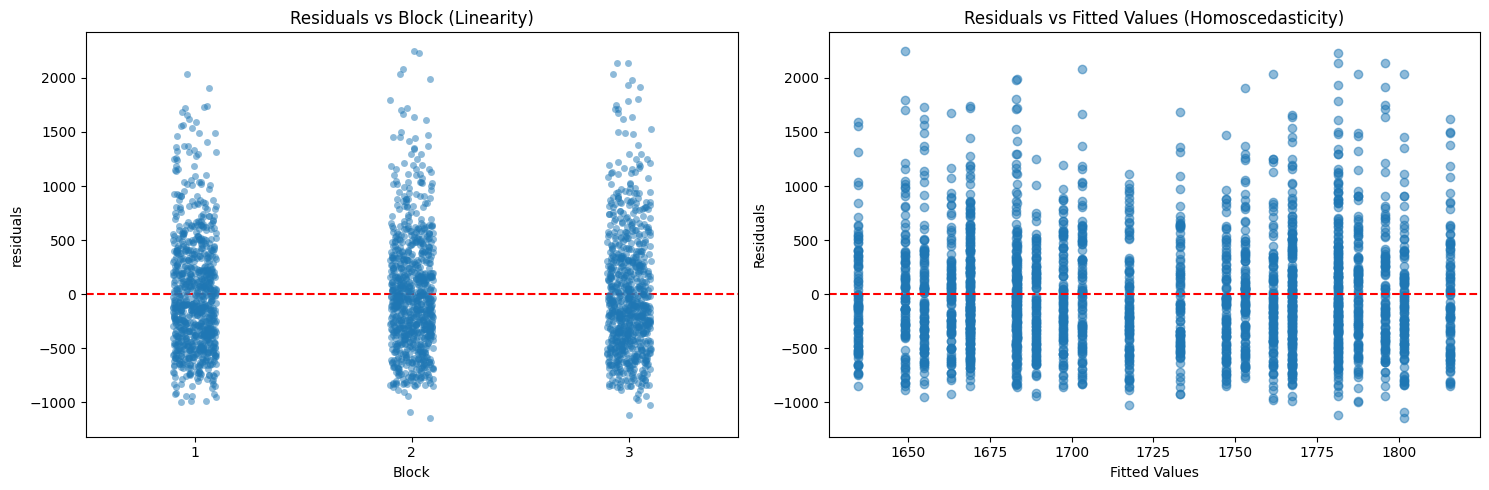

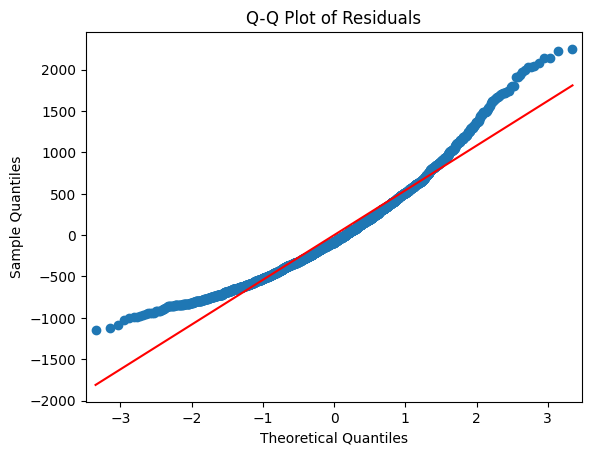

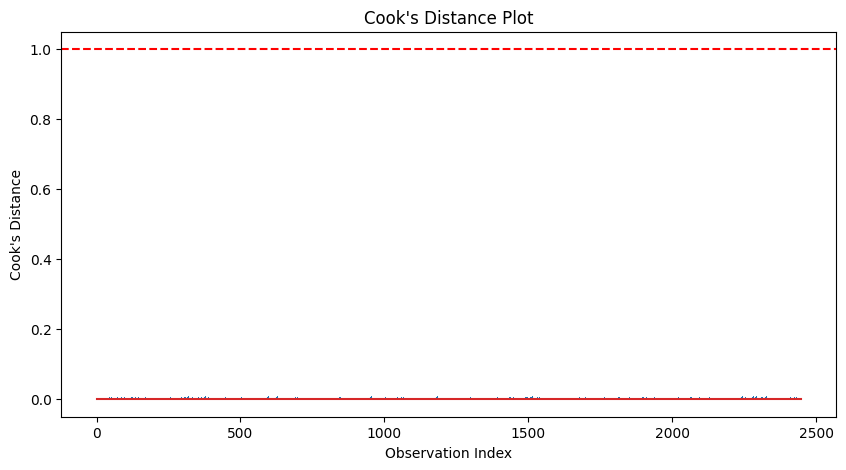

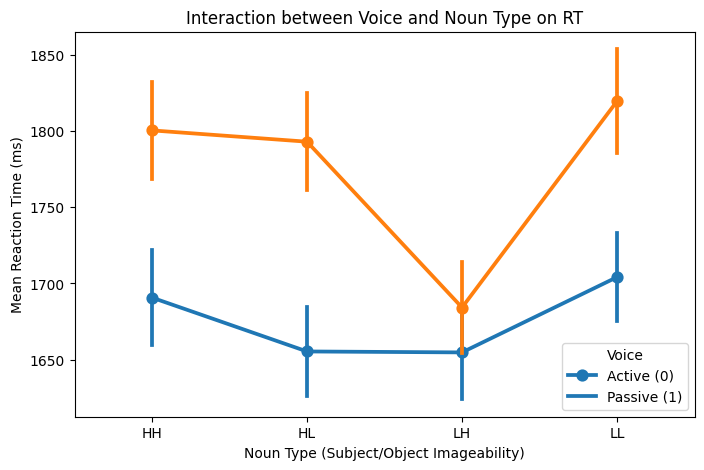

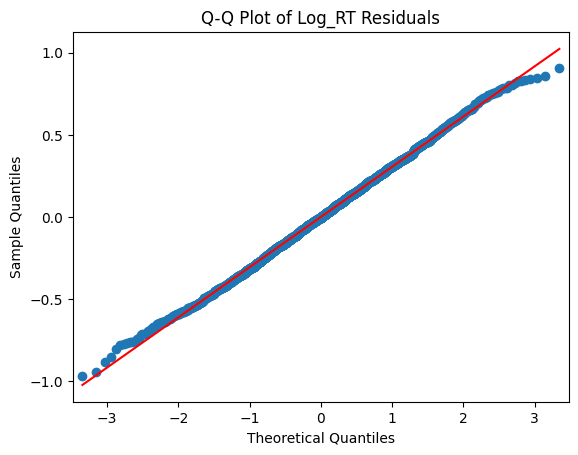

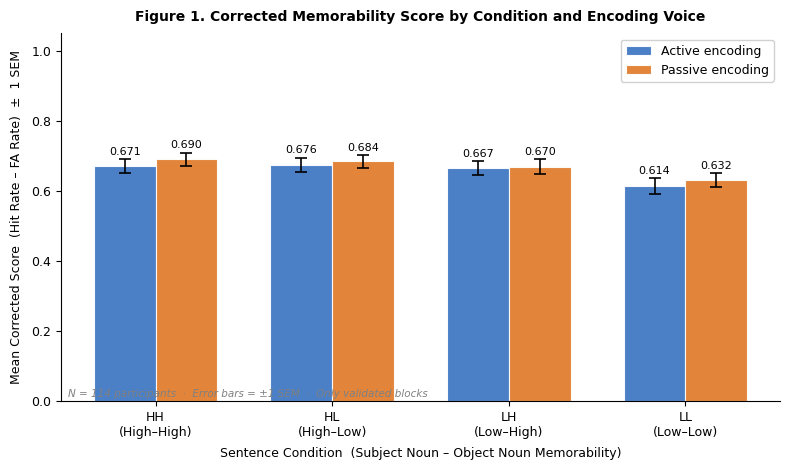

  Saved: ./output/descriptive_analysis_outputs\figure1_corrected_score.png


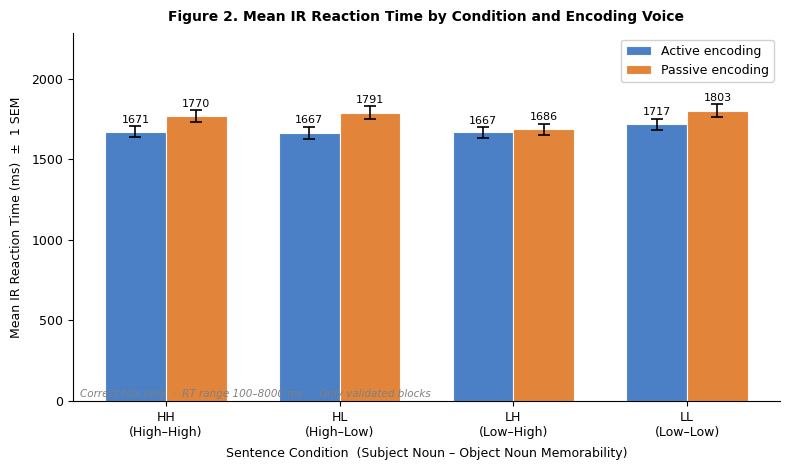

  Saved: ./output/descriptive_analysis_outputs\figure2_reaction_time.png


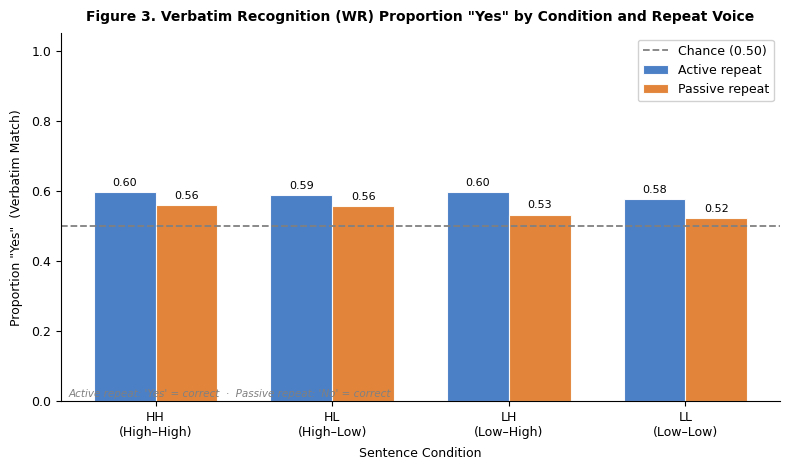

  Saved: ./output/descriptive_analysis_outputs\figure3_wr_proportion_yes.png

All done. Outputs saved to: ./output/descriptive_analysis_outputs/
Files:
  figure1_corrected_score.png
  figure2_reaction_time.png
  figure3_wr_proportion_yes.png
  per_condition_per_participant.csv
  per_participant_overall.csv
  table2_overall_stats.csv
  table3_per_condition.csv
  table4_wr_breakdown.csv


In [ ]:
"""
Sentence Memorability — Results Analysis
=========================================
Reproduces exactly the tables, figures, and statistics in Report 1 Section 3:
  - Table 2  : Overall recognition performance summary
  - Table 3  : Per-condition performance (corrected score, RT)
  - Table 4  : WR verbatim recognition breakdown
  - Figure 1 : Corrected memorability score by condition x voice
  - Figure 2 : Mean IR reaction time by condition x voice
  - Figure 3 : WR proportion "Yes" by condition x voice
  - All inferential stats (t-tests, ANOVA, binomial, chi-squared)

KEY FIX vs previous version
----------------------------
"Rest Phase started" rows have Stimulus=N/A and were being filtered out before
block assignment — so all rows ended up in block 1 and per-block validation
never fired correctly.  Fix: parse the RAW file (all rows including N/A) first
to get Rest Phase timestamps, then use those timestamps to assign block IDs to
the filtered main rows.

Usage
-----
    python results_analysis.py
    python results_analysis.py --logs_dir ./logs --out_dir ./output

Requirements
------------
    pip install pandas matplotlib scipy numpy
"""
%matplotlib inline
import os, csv, io, argparse, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

# ── CLI args ──────────────────────────────────────────────────────────────────
parser = argparse.ArgumentParser()
parser.add_argument("--logs_dir", default="./NewLogsAnonymized")
parser.add_argument("--out_dir",  default="./output/descriptive_analysis_outputs")
args, unknown = parser.parse_known_args()

LOGS_DIR = "./NewLogsAnonymized"
OUT_DIR  = args.out_dir
os.makedirs(OUT_DIR, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
RAW_TO_COND = {"HH": "HH", "HVL": "HL", "LVH": "LH", "LVL": "LL"}
COND_ORDER  = ["HH", "HL", "LH", "LL"]
COND_LABELS = ["HH\n(High–High)", "HL\n(High–Low)", "LH\n(Low–High)", "LL\n(Low–Low)"]
VOICE_ORDER = ["Active", "Passive"]
COLORS      = {"Active": "#3B74C2", "Passive": "#E07B2A"}


# ═════════════════════════════════════════════════════════════════════════════
# 1.  PARSE LOG FILE
#     Returns:
#       all_rows  – every non-Practice row (including Rest Phase / Stimulus=N/A)
#       main_rows – rows that carry a real stimulus value
# ═════════════════════════════════════════════════════════════════════════════
def parse_log(filepath):
    with open(filepath, "r", encoding="utf-8-sig") as f:
        content = f.read().replace("\r\n", "\n")
    reader   = csv.DictReader(io.StringIO(content))
    all_rows  = [r for r in reader if "Practice" not in r["Event"]]
    main_rows = [r for r in all_rows  if r["Stimulus"] != "N/A"]
    return all_rows, main_rows


# ═════════════════════════════════════════════════════════════════════════════
# 2.  ASSIGN BLOCK IDs VIA TIMESTAMPS
#     "Rest Phase started" rows have Stimulus=N/A so they only exist in
#     all_rows.  We extract their timestamps and use them as block boundaries
#     when tagging each main_row.
#
#     With 2 rest phases:
#       block 1 : ts  <  rest[0]
#       block 2 : rest[0] <= ts  <  rest[1]
#       block 3 : ts >= rest[1]
# ═════════════════════════════════════════════════════════════════════════════
def assign_blocks(all_rows, main_rows):
    rest_ts = sorted(
        int(r["Timestamp"])
        for r in all_rows
        if "Rest Phase" in r["Event"]
    )

    def get_block(ts):
        ts  = int(ts)
        bid = 1
        for boundary in rest_ts:
            if ts > boundary:
                bid += 1
        return bid

    for r in main_rows:
        r["_block"] = get_block(r["Timestamp"])


# ═════════════════════════════════════════════════════════════════════════════
# 3.  BLOCK VALIDATION
#     Criterion: Correct > (Wrong / 2) + Missed
# ═════════════════════════════════════════════════════════════════════════════
def block_passes(block_rows):
    correct = sum(
        1 for r in block_rows
        if r["isValidation"] == "true"
        and r["Event"]       == "Validation IR pressed"
        and r["Accuracy IR"] == "1"
    )
    wrong = sum(
        1 for r in block_rows
        if r["isValidation"] == "true"
        and r["Event"]       == "Validation Wrong IR pressed"
    )
    val_shown = {
        r["Stimulus"] for r in block_rows
        if r["isValidation"] == "true"
        and r["isRepeat"]    == "true"
        and r["Event"]       == "Sentence shown"
    }
    val_responded = {
        r["Stimulus"] for r in block_rows
        if r["isValidation"] == "true"
        and r["isRepeat"]    == "true"
        and r["Event"] in ("Validation IR pressed",
                           "Validation Wrong IR pressed")
    }
    missed = len(val_shown - val_responded)
    return correct > (wrong / 2) + missed


# ═════════════════════════════════════════════════════════════════════════════
# 4.  PROCESS ONE PARTICIPANT
# ═════════════════════════════════════════════════════════════════════════════
def process_participant(all_rows, main_rows, pid):
    assign_blocks(all_rows, main_rows)

    all_blocks   = sorted({r["_block"] for r in main_rows})
    valid_blocks = {
        b for b in all_blocks
        if block_passes([r for r in main_rows if r["_block"] == b])
    }

    if not valid_blocks:
        return None, None

    vrows = [r for r in main_rows if r["_block"] in valid_blocks]

    # ── false alarm rate ──────────────────────────────────────────────────────
    filler_shown   = [r for r in vrows
                      if r["isTarget"]      != "true"
                      and r["isRepeat"]     != "true"
                      and r["isValidation"] != "true"
                      and r["Event"]        == "Sentence shown"]
    filler_pressed = [r for r in vrows
                      if r["isTarget"]      != "true"
                      and r["isRepeat"]     != "true"
                      and r["isValidation"] != "true"
                      and r["Event"]        == "IR pressed"]
    n_filler = len(filler_shown)
    n_fa     = len(filler_pressed)
    fa_rate  = n_fa / n_filler if n_filler else 0.0

    # ── per-condition cells ───────────────────────────────────────────────────
    cell_records = []
    for raw_cond, cond in RAW_TO_COND.items():
        for voice_code, voice_label in [("A", "Active"), ("P", "Passive")]:

            targets = [r for r in vrows
                       if r["isTarget"]      == "true"
                       and r["isRepeat"]     == "true"
                       and r["isValidation"] != "true"
                       and r["Event"]        == "Sentence shown"
                       and r["Stimulus"].startswith(raw_cond + "_")
                       and r["Stimulus"].endswith("_" + voice_code)]
            n_total = len(targets)
            if n_total == 0:
                continue

            hits = [r for r in vrows
                    if r["isTarget"]      == "true"
                    and r["isRepeat"]     == "true"
                    and r["isValidation"] != "true"
                    and r["Event"]        == "IR pressed"
                    and r["Accuracy IR"]  == "1"
                    and r["Stimulus"].startswith(raw_cond + "_")
                    and r["Stimulus"].endswith("_" + voice_code)]
            n_hits   = len(hits)
            hit_rate = n_hits / n_total
            corr     = hit_rate - fa_rate

            rts = [int(r["Reaction_time_IR"]) for r in hits
                   if r["Reaction_time_IR"] not in ("N/A", "")
                   and 100 <= int(r["Reaction_time_IR"]) <= 8000]
            mean_rt = float(np.mean(rts)) if rts else np.nan

            wr_yes = sum(1 for r in vrows
                         if r["isRepeat"]  == "true"
                         and r["isTarget"] == "true"
                         and r["Event"]    == "WR pressed"
                         and r["Button"]   == "Yes"
                         and r["Stimulus"].startswith(raw_cond + "_")
                         and r["Stimulus"].endswith("_" + voice_code))
            wr_no  = sum(1 for r in vrows
                         if r["isRepeat"]  == "true"
                         and r["isTarget"] == "true"
                         and r["Event"]    == "WR pressed"
                         and r["Button"]   == "No"
                         and r["Stimulus"].startswith(raw_cond + "_")
                         and r["Stimulus"].endswith("_" + voice_code))

            cell_records.append({
                "participant_ID": pid,
                "condition":      cond,
                "encoding_voice": voice_label,
                "n_total":        n_total,
                "n_hits":         n_hits,
                "hit_rate":       hit_rate,
                "fa_rate":        fa_rate,
                "corr_score":     corr,
                "mean_rt":        mean_rt,
                "wr_yes":         wr_yes,
                "wr_no":          wr_no,
            })

    # ── overall stats ─────────────────────────────────────────────────────────
    all_target_shown = [r for r in vrows
                        if r["isTarget"]      == "true"
                        and r["isRepeat"]     == "true"
                        and r["isValidation"] != "true"
                        and r["Event"]        == "Sentence shown"]
    all_hits = [r for r in vrows
                if r["isTarget"]      == "true"
                and r["isRepeat"]     == "true"
                and r["isValidation"] != "true"
                and r["Event"]        == "IR pressed"
                and r["Accuracy IR"]  == "1"]
    hit_rts  = [int(r["Reaction_time_IR"]) for r in all_hits
                if r["Reaction_time_IR"] not in ("N/A", "")
                and 100 <= int(r["Reaction_time_IR"]) <= 8000]

    n_targets  = len(all_target_shown)
    n_hits_tot = len(all_hits)
    overall_hr = n_hits_tot / n_targets if n_targets else 0.0

    overall = {
        "participant_ID":  pid,
        "n_targets":       n_targets,
        "n_hits":          n_hits_tot,
        "n_missed":        n_targets - n_hits_tot,
        "hit_rate":        overall_hr,
        "n_filler":        n_filler,
        "n_fa":            n_fa,
        "fa_rate":         fa_rate,
        "corr_score":      overall_hr - fa_rate,
        "mean_rt":         float(np.mean(hit_rts))   if hit_rts else np.nan,
        "median_rt":       float(np.median(hit_rts)) if hit_rts else np.nan,
        "sd_rt":           float(np.std(hit_rts))    if hit_rts else np.nan,
        "min_rt":          min(hit_rts) if hit_rts else np.nan,
        "max_rt":          max(hit_rts) if hit_rts else np.nan,
        "n_valid_blocks":  len(valid_blocks),
    }
    return cell_records, overall


# ═════════════════════════════════════════════════════════════════════════════
# 5.  LOAD ALL LOG FILES
# ═════════════════════════════════════════════════════════════════════════════
print(f"Loading logs from : {LOGS_DIR}")
log_files = sorted(f for f in os.listdir(LOGS_DIR)
                   if f.endswith(".log") or f.endswith(".csv"))
print(f"  {len(log_files)} files found\n")

all_cells   = []
all_overall = []
excluded    = []

for fname in log_files:
    try:
        all_rows, main_rows = parse_log(os.path.join(LOGS_DIR, fname))
        if not main_rows:
            continue
        pid = main_rows[0]["participant_ID"]
        cells, overall = process_participant(all_rows, main_rows, pid)
        if cells is None:
            excluded.append(pid)
        else:
            all_cells.extend(cells)
            all_overall.append(overall)
    except Exception as e:
        print(f"  ERROR {fname}: {e}")

df      = pd.DataFrame(all_cells)
df_over = pd.DataFrame(all_overall)
N       = df["participant_ID"].nunique()

print(f"Participants included : {N}")
print(f"Participants excluded : {len(excluded)}"
      + (f"  {excluded}" if excluded else ""))
print(f"Condition-level rows  : {len(df)}\n")

df.to_csv(     os.path.join(OUT_DIR, "per_condition_per_participant.csv"), index=False)
df_over.to_csv(os.path.join(OUT_DIR, "per_participant_overall.csv"),       index=False)


# ═════════════════════════════════════════════════════════════════════════════
# 6.  AGGREGATE  (mean ± SEM per condition x voice cell)
# ═════════════════════════════════════════════════════════════════════════════
agg = (df.groupby(["condition", "encoding_voice"])
         .agg(
             mean_corr = ("corr_score", "mean"),
             sem_corr  = ("corr_score", lambda x: x.sem()),
             mean_rt   = ("mean_rt",    "mean"),
             sem_rt    = ("mean_rt",    lambda x: x.sem()),
             n         = ("participant_ID", "nunique"),
         )
         .reset_index())


# ═════════════════════════════════════════════════════════════════════════════
# 7.  TABLE 2  —  Overall recognition performance
# ═════════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("TABLE 2 — Overall Recognition Performance")
print("=" * 65)

table2 = pd.DataFrame({
    "Metric": [
        "Participants included (N)",
        "Total recognition trials",
        "Mean correct hits per participant",
        "Mean hit rate",
        "Mean missed targets per participant",
        "Mean false alarms per participant",
        "Mean FA rate",
        "Mean corrected memorability score",
        "Mean IR reaction time — hits",
        "Mean median RT — hits",
        "Mean valid blocks per participant",
    ],
    "Value": [
        str(N),
        str(int(df_over["n_targets"].sum())),
        f"{df_over['n_hits'].mean():.1f}  (total = {int(df_over['n_hits'].sum())})",
        f"{df_over['hit_rate'].mean():.3f}",
        f"{df_over['n_missed'].mean():.2f}  (total = {int(df_over['n_missed'].sum())})",
        f"{df_over['n_fa'].mean():.1f}  (total = {int(df_over['n_fa'].sum())})",
        f"{df_over['fa_rate'].mean():.3f}",
        f"{df_over['corr_score'].mean():.3f}",
        f"{df_over['mean_rt'].mean():.1f} ms  (SD = {df_over['sd_rt'].mean():.1f})",
        f"{df_over['median_rt'].mean():.1f} ms",
        f"{df_over['n_valid_blocks'].mean():.2f}",
    ]
})
print(table2.to_string(index=False))
table2.to_csv(os.path.join(OUT_DIR, "table2_overall_stats.csv"), index=False)


# ═════════════════════════════════════════════════════════════════════════════
# 8.  TABLE 3  —  Per-condition performance
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("TABLE 3 — Per-Condition Performance (mean across participants)")
print("=" * 65)

t3_rows = []
for cond in COND_ORDER:
    for voice in VOICE_ORDER:
        raw = df[(df["condition"] == cond) & (df["encoding_voice"] == voice)]
        if raw.empty:
            continue
        t3_rows.append({
            "Condition":             cond,
            "Voice":                 voice,
            "Mean Hits / Total":     f"{raw['n_hits'].mean():.1f} / {raw['n_total'].mean():.1f}",
            "Hit Rate (M)":          f"{raw['hit_rate'].mean():.3f}",
            "FA Rate (M)":           f"{raw['fa_rate'].mean():.3f}",
            "Corr. Score (M ± SEM)": f"{raw['corr_score'].mean():.3f} ± {raw['corr_score'].sem():.3f}",
            "Mean RT ms (M ± SEM)":  f"{raw['mean_rt'].mean():.1f} ± {raw['mean_rt'].sem():.1f}",
        })

table3 = pd.DataFrame(t3_rows)
print(table3.to_string(index=False))
table3.to_csv(os.path.join(OUT_DIR, "table3_per_condition.csv"), index=False)


# ═════════════════════════════════════════════════════════════════════════════
# 9.  TABLE 4  —  WR verbatim recognition
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("TABLE 4 — WR Verbatim Recognition (summed across all participants)")
print("=" * 65)

t4_rows = []
grand = {"ay": 0, "an": 0, "py": 0, "pn": 0}

for cond in COND_ORDER:
    act = df[(df["condition"] == cond) & (df["encoding_voice"] == "Active")]
    pas = df[(df["condition"] == cond) & (df["encoding_voice"] == "Passive")]
    ay, an = int(act["wr_yes"].sum()), int(act["wr_no"].sum())
    py, pn = int(pas["wr_yes"].sum()), int(pas["wr_no"].sum())
    at, pt = ay + an, py + pn
    grand["ay"] += ay; grand["an"] += an
    grand["py"] += py; grand["pn"] += pn
    t4_rows.append({
        "Condition":     cond,
        "Active – Yes":  f"{ay}  ({100*ay/at:.0f}%)" if at else "—",
        "Active – No":   f"{an}  ({100*an/at:.0f}%)" if at else "—",
        "Passive – Yes": f"{py}  ({100*py/pt:.0f}%)" if pt else "—",
        "Passive – No":  f"{pn}  ({100*pn/pt:.0f}%)" if pt else "—",
    })

at = grand["ay"] + grand["an"]
pt = grand["py"] + grand["pn"]
t4_rows.append({
    "Condition":     "Total",
    "Active – Yes":  f"{grand['ay']}  ({100*grand['ay']/at:.0f}%)",
    "Active – No":   f"{grand['an']}  ({100*grand['an']/at:.0f}%)",
    "Passive – Yes": f"{grand['py']}  ({100*grand['py']/pt:.0f}%)",
    "Passive – No":  f"{grand['pn']}  ({100*grand['pn']/pt:.0f}%)",
})

table4 = pd.DataFrame(t4_rows)
print(table4.to_string(index=False))
table4.to_csv(os.path.join(OUT_DIR, "table4_wr_breakdown.csv"), index=False)


# ═════════════════════════════════════════════════════════════════════════════
# 10.  INFERENTIAL STATISTICS
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 65)
print("INFERENTIAL STATISTICS")
print("=" * 65)

# [i] Binomial: hit rate vs 0.5
tot_hits = int(df_over["n_hits"].sum())
tot_targ = int(df_over["n_targets"].sum())
b_hit    = stats.binomtest(tot_hits, tot_targ, 0.5, alternative="greater")
print(f"\n[i]   Binomial — Hit rate vs chance (0.50)")
print(f"      Hits = {tot_hits} / {tot_targ}   HR = {tot_hits/tot_targ:.3f}")
print(f"      p = {b_hit.pvalue:.2e}")

# [ii] Binomial: FA rate vs 0.5
tot_fa   = int(df_over["n_fa"].sum())
tot_fill = int(df_over["n_filler"].sum())
b_fa     = stats.binomtest(tot_fa, tot_fill, 0.5, alternative="less")
print(f"\n[ii]  Binomial — FA rate vs chance (0.50)")
print(f"      FAs = {tot_fa} / {tot_fill}   FAR = {tot_fa/tot_fill:.3f}")
print(f"      p = {b_fa.pvalue:.2e}")

# [iii] Independent t-test: Active vs Passive corrected score
act_cs = df[df["encoding_voice"] == "Active"]["corr_score"].dropna()
pas_cs = df[df["encoding_voice"] == "Passive"]["corr_score"].dropna()
t3v, p3v = stats.ttest_ind(act_cs, pas_cs)
print(f"\n[iii] Independent t-test — Corrected Score: Active vs Passive")
print(f"      Active  M={act_cs.mean():.4f}  SD={act_cs.std():.4f}  n={len(act_cs)}")
print(f"      Passive M={pas_cs.mean():.4f}  SD={pas_cs.std():.4f}  n={len(pas_cs)}")
print(f"      t({len(act_cs)+len(pas_cs)-2}) = {t3v:.3f},  p = {p3v:.4f}")

# [iv] Independent t-test: Active vs Passive RT
act_rt = df[df["encoding_voice"] == "Active"]["mean_rt"].dropna()
pas_rt = df[df["encoding_voice"] == "Passive"]["mean_rt"].dropna()
t4v, p4v = stats.ttest_ind(act_rt, pas_rt)
print(f"\n[iv]  Independent t-test — RT: Active vs Passive")
print(f"      Active  M={act_rt.mean():.1f} ms  SD={act_rt.std():.1f}  n={len(act_rt)}")
print(f"      Passive M={pas_rt.mean():.1f} ms  SD={pas_rt.std():.1f}  n={len(pas_rt)}")
print(f"      t({len(act_rt)+len(pas_rt)-2}) = {t4v:.3f},  p = {p4v:.4f}")

# [v] One-way ANOVA: corrected score across 4 conditions
grps_cs = [df[df["condition"] == c]["corr_score"].dropna().values for c in COND_ORDER]
fv, pv  = stats.f_oneway(*grps_cs)
df_b    = len(COND_ORDER) - 1
df_w    = sum(len(g) for g in grps_cs) - len(COND_ORDER)
print(f"\n[v]   One-Way ANOVA — Corrected Score across 4 conditions")
for c, g in zip(COND_ORDER, grps_cs):
    print(f"      {c}: M={g.mean():.4f}  SD={g.std():.4f}  n={len(g)}")
print(f"      F({df_b}, {df_w}) = {fv:.3f},  p = {pv:.4f}")

# [vi] One-way ANOVA: RT across 4 conditions
grps_rt  = [df[df["condition"] == c]["mean_rt"].dropna().values for c in COND_ORDER]
frv, prv = stats.f_oneway(*grps_rt)
df_br    = len(COND_ORDER) - 1
df_wr    = sum(len(g) for g in grps_rt) - len(COND_ORDER)
print(f"\n[vi]  One-Way ANOVA — RT across 4 conditions")
for c, g in zip(COND_ORDER, grps_rt):
    print(f"      {c}: M={g.mean():.1f} ms  SD={g.std():.1f}  n={len(g)}")
print(f"      F({df_br}, {df_wr}) = {frv:.3f},  p = {prv:.4f}")

# [vii] Chi-squared: WR Yes/No x voice
aw  = df[df["encoding_voice"] == "Active"][["wr_yes",  "wr_no"]].sum()
pw  = df[df["encoding_voice"] == "Passive"][["wr_yes", "wr_no"]].sum()
ct  = np.array([[aw["wr_yes"], aw["wr_no"]], [pw["wr_yes"], pw["wr_no"]]])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct, correction=False)
print(f"\n[vii] Chi-squared — WR Yes/No x encoding voice")
print(f"      Active  Yes={int(aw['wr_yes'])}  No={int(aw['wr_no'])}"
      f"  prop_yes={aw['wr_yes']/(aw['wr_yes']+aw['wr_no']):.2f}")
print(f"      Passive Yes={int(pw['wr_yes'])}  No={int(pw['wr_no'])}"
      f"  prop_yes={pw['wr_yes']/(pw['wr_yes']+pw['wr_no']):.2f}")
print(f"      chi2({dof}) = {chi2:.3f},  p = {p_chi:.4f}")

# [viii] Paired t-test: HH vs LL
hh_p = df[df["condition"] == "HH"].groupby("participant_ID")["corr_score"].mean()
ll_p = df[df["condition"] == "LL"].groupby("participant_ID")["corr_score"].mean()
prd  = pd.DataFrame({"HH": hh_p, "LL": ll_p}).dropna()
if len(prd) > 1:
    t8, p8 = stats.ttest_rel(prd["HH"], prd["LL"])
    print(f"\n[viii] Paired t-test — HH vs LL corrected score")
    print(f"      HH M={prd['HH'].mean():.4f}  LL M={prd['LL'].mean():.4f}  n={len(prd)}")
    print(f"      t({len(prd)-1}) = {t8:.3f},  p = {p8:.4f}")

# [ix] Paired t-test: HL vs LH (position effect)
hl_p  = df[df["condition"] == "HL"].groupby("participant_ID")["corr_score"].mean()
lh_p  = df[df["condition"] == "LH"].groupby("participant_ID")["corr_score"].mean()
pos_d = pd.DataFrame({"HL": hl_p, "LH": lh_p}).dropna()
if len(pos_d) > 1:
    t9, p9 = stats.ttest_rel(pos_d["HL"], pos_d["LH"])
    print(f"\n[ix]  Paired t-test — HL vs LH (position effect)")
    print(f"      HL M={pos_d['HL'].mean():.4f}  LH M={pos_d['LH'].mean():.4f}  n={len(pos_d)}")
    print(f"      t({len(pos_d)-1}) = {t9:.3f},  p = {p9:.4f}")

print(f"\nBonferroni-corrected alpha (0.05 / 9 tests) = {0.05/9:.5f}")


# ═════════════════════════════════════════════════════════════════════════════
# 11.  PLOT HELPERS
# ═════════════════════════════════════════════════════════════════════════════
def style_ax(ax, title, xlabel, ylabel):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(labelsize=9)
    ax.set_title(title,   fontsize=10, fontweight="bold", pad=9)
    ax.set_xlabel(xlabel, fontsize=9,  labelpad=6)
    ax.set_ylabel(ylabel, fontsize=9,  labelpad=6)

def save(fig, name):
    path = os.path.join(OUT_DIR, name)
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print(f"  Saved: {path}")

x = np.arange(len(COND_ORDER))
w = 0.35


# ═════════════════════════════════════════════════════════════════════════════
# 12.  FIGURE 1  —  Corrected Memorability Score by Condition x Voice
# ═════════════════════════════════════════════════════════════════════════════
print("\nGenerating figures …")

fig, ax = plt.subplots(figsize=(8, 4.8))
for i, voice in enumerate(VOICE_ORDER):
    sub   = agg[agg["encoding_voice"] == voice].set_index("condition").reindex(COND_ORDER)
    means = sub["mean_corr"].values.astype(float)
    sems  = np.nan_to_num(sub["sem_corr"].values.astype(float), nan=0.0)
    offset = (i - 0.5) * w

    bars = ax.bar(x + offset, means, w,
                  color=COLORS[voice], label=f"{voice} encoding",
                  edgecolor="white", linewidth=0.8, alpha=0.92,
                  yerr=sems, capsize=4,
                  error_kw=dict(elinewidth=1.2, capthick=1.2))

    for bar, m, se in zip(bars, means, sems):
        if not np.isnan(m):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + se + 0.006,
                    f"{m:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS, fontsize=9)
ax.set_ylim(0, 1.05)
ax.axhline(0, color="black", linewidth=0.5)
ax.legend(fontsize=9, framealpha=0.9)
style_ax(ax,
         title="Figure 1. Corrected Memorability Score by Condition and Encoding Voice",
         xlabel="Sentence Condition  (Subject Noun – Object Noun Memorability)",
         ylabel="Mean Corrected Score  (Hit Rate – FA Rate)  ±  1 SEM")
ax.text(0.01, 0.01,
        f"N = {N} participants  ·  Error bars = ±1 SEM  ·  Only validated blocks",
        transform=ax.transAxes, fontsize=7.5, color="gray", style="italic")
fig.tight_layout()
plt.show()
save(fig, "figure1_corrected_score.png")


# ═════════════════════════════════════════════════════════════════════════════
# 13.  FIGURE 2  —  Mean IR Reaction Time by Condition x Voice
# ═════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 4.8))
for i, voice in enumerate(VOICE_ORDER):
    sub   = agg[agg["encoding_voice"] == voice].set_index("condition").reindex(COND_ORDER)
    means = sub["mean_rt"].values.astype(float)
    sems  = np.nan_to_num(sub["sem_rt"].values.astype(float), nan=0.0)
    offset = (i - 0.5) * w

    bars = ax.bar(x + offset, means, w,
                  color=COLORS[voice], label=f"{voice} encoding",
                  edgecolor="white", linewidth=0.8, alpha=0.92,
                  yerr=sems, capsize=4,
                  error_kw=dict(elinewidth=1.2, capthick=1.2))

    for bar, m, se in zip(bars, means, sems):
        if not np.isnan(m):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + se + 8,
                    f"{int(round(m))}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS, fontsize=9)
ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
ax.legend(fontsize=9, framealpha=0.9)
style_ax(ax,
         title="Figure 2. Mean IR Reaction Time by Condition and Encoding Voice",
         xlabel="Sentence Condition  (Subject Noun – Object Noun Memorability)",
         ylabel="Mean IR Reaction Time (ms)  ±  1 SEM")
ax.text(0.01, 0.01,
        "Correct hits only  ·  RT range 100–8000 ms  ·  Only validated blocks",
        transform=ax.transAxes, fontsize=7.5, color="gray", style="italic")
fig.tight_layout()
plt.show()
save(fig, "figure2_reaction_time.png")


# ═════════════════════════════════════════════════════════════════════════════
# 14.  FIGURE 3  —  WR Proportion "Yes" by Condition x Voice
# ═════════════════════════════════════════════════════════════════════════════
wr_agg = (df[df["condition"].isin(COND_ORDER)]
          .groupby(["condition", "encoding_voice"])
          .agg(yes=("wr_yes", "sum"), no=("wr_no", "sum"))
          .reset_index())
wr_agg["total"]    = wr_agg["yes"] + wr_agg["no"]
wr_agg["prop_yes"] = wr_agg["yes"] / wr_agg["total"]

fig, ax = plt.subplots(figsize=(8, 4.8))
for i, voice in enumerate(VOICE_ORDER):
    sub    = (wr_agg[wr_agg["encoding_voice"] == voice]
              .set_index("condition").reindex(COND_ORDER))
    props  = sub["prop_yes"].values.astype(float)
    offset = (i - 0.5) * w

    bars = ax.bar(x + offset, props, w,
                  color=COLORS[voice], label=f"{voice} repeat",
                  edgecolor="white", linewidth=0.8, alpha=0.92)

    for bar, p in zip(bars, props):
        if not np.isnan(p):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.012,
                    f"{p:.2f}", ha="center", va="bottom", fontsize=8)

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1.3, label="Chance (0.50)")
ax.set_xticks(x)
ax.set_xticklabels(COND_LABELS, fontsize=9)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, framealpha=0.9)
style_ax(ax,
         title='Figure 3. Verbatim Recognition (WR) Proportion "Yes" by Condition and Repeat Voice',
         xlabel="Sentence Condition",
         ylabel='Proportion "Yes"  (Verbatim Match)')
ax.text(0.01, 0.01,
        "Active repeat: 'Yes' = correct  ·  Passive repeat: 'No' = correct",
        transform=ax.transAxes, fontsize=7.5, color="gray", style="italic")
fig.tight_layout()
plt.show()
save(fig, "figure3_wr_proportion_yes.png")


# ═════════════════════════════════════════════════════════════════════════════
# 15.  DONE
# ═════════════════════════════════════════════════════════════════════════════
print(f"\nAll done. Outputs saved to: {OUT_DIR}/")
print("Files:")
for f in sorted(os.listdir(OUT_DIR)):
    print(f"  {f}")

# OLS GLM and Logistics GLM

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION — adjust paths if your folder names differ
# ─────────────────────────────────────────────────────────────────────────────
COND_FILE    = "./output/descriptive_analysis_outputs/per_condition_per_participant.csv"
OVERALL_FILE = "./output/descriptive_analysis_outputs/per_participant_overall.csv"
OUT_DIR      = "./output"
os.makedirs(OUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# REPORT LOGGER — mirrors the out() / sec() pattern from Report 1 code
# ─────────────────────────────────────────────────────────────────────────────
report_lines = []

def sec(title):
    line = "=" * 65
    block = f"\n{line}\n{title}\n{line}"
    print(block)
    report_lines.append(block)

def out(text=""):
    print(text)
    report_lines.append(str(text))

def fmt_p(p):
    if p < 0.001:
        return "< .001"
    return f"= {p:.4f}"

def save_report():
    path = os.path.join(OUT_DIR, "glm_results_report.txt")
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(report_lines))
    print(f"\n  Report saved to: {path}")

# ─────────────────────────────────────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
sec("LOADING DATA")

df_cond    = pd.read_csv(COND_FILE)
df_overall = pd.read_csv(OVERALL_FILE)

out(f"  Condition-level rows      : {len(df_cond)}")
out(f"  Participants (cond file)  : {df_cond['participant_ID'].nunique()}")
out(f"  Overall-level rows        : {len(df_overall)}")
out()
out("  Columns in condition file :")
out(f"    {list(df_cond.columns)}")
out("  Columns in overall file   :")
out(f"    {list(df_overall.columns)}")

# ═════════════════════════════════════════════════════════════════════════════
#
#  GLM 1 — OLS GLM ON CORRECTED MEMORABILITY SCORE
#
#  Unit of analysis: one row per participant x condition x voice (8 rows/participant)
#  Outcome        : corr_score (continuous, hit_rate - fa_rate)
#  Fixed predictors: voice (Active=0, Passive=1)
#                    condition dummy-coded (HH=reference)
#                    block (1/2/3) — covariate for practice effect
#  Covariates     : individual FA rate (between-subject response bias)
#                   individual median RT (between-subject processing speed)
#  Why OLS here   : corr_score is continuous; we verify residual normality and
#                   homoscedasticity below; if violated, we switch to HC3 SEs.
#
# ═════════════════════════════════════════════════════════════════════════════

sec("GLM 1 — OLS GLM ON CORRECTED MEMORABILITY SCORE")

# ── Step 1: Merge individual-level covariates into condition-level data ───────
#
# fa_rate and median_rt exist in df_overall at the participant level.
# Each participant has one fa_rate and one median_rt (computed across all their
# valid trials). We merge these into the condition-level frame so each row
# carries its participant's covariate values.
#
# Justification for using participant-level (not condition-level) covariates:
# FA rate is a global response-tendency measure — it reflects how liberally a
# participant presses the spacebar regardless of condition. Using it as a
# between-subject covariate (constant within participant) is correct. If we
# used condition-level FA rates, we would be controlling for something that
# varies by condition, which would risk over-controlling and removing real
# experimental variance.

out("\n  Step 1: Merging participant-level covariates...")

# We rename the covariate columns from df_overall to avoid collision with
# same-named columns already present in df_cond (e.g. fa_rate exists in both).
# The overall-file versions are participant-level aggregates; we suffix them
# with _overall to make this explicit.
covariate_map = {
    "fa_rate" : "fa_rate_overall",
    "median_rt": "median_rt_overall",
}

available_raw = [c for c in covariate_map if c in df_overall.columns]
missing_raw   = [c for c in covariate_map if c not in df_overall.columns]

if missing_raw:
    out(f"  WARNING: These covariate columns not found in overall file: {missing_raw}")
    out("  They will be excluded from GLM 1 covariates.")

covariates_df = df_overall[["participant_ID"] + available_raw].copy()
covariates_df = covariates_df.rename(columns=covariate_map)
available_renamed = [covariate_map[c] for c in available_raw]

glm1_data = df_cond.merge(covariates_df, on="participant_ID", how="left")

out(f"  Rows after merge: {len(glm1_data)}")
out(f"  Missing covariate values: {glm1_data[available_renamed].isna().sum().to_dict()}")

glm1_data = glm1_data.dropna(subset=["corr_score"])
out(f"  Rows after dropping missing corr_score: {len(glm1_data)}")


glm1_data["voice_coded"] = (glm1_data["encoding_voice"] == "Passive").astype(int)

# Condition dummies — HH is reference (omitted)
for cond in ["HL", "LH", "LL"]:
    glm1_data[f"cond_{cond}"] = (glm1_data["condition"] == cond).astype(int)


for col in ["fa_rate_overall", "median_rt_overall"]:
    if col in glm1_data.columns:
        glm1_data[f"{col}_z"] = (
            (glm1_data[col] - glm1_data[col].mean()) / glm1_data[col].std()
        )
        out(f"  Standardised {col}: M={glm1_data[col].mean():.4f}, "
            f"SD={glm1_data[col].std():.4f}")

# ── Step 4: Build predictor matrix ────────────────────────────────────────────

predictor_cols = ["voice_coded", "cond_HL", "cond_LH", "cond_LL"]
covariate_z_cols = [c + "_z" for c in ["fa_rate_overall", "median_rt_overall"]
                    if c in glm1_data.columns]
all_predictors = predictor_cols + covariate_z_cols

# Drop rows where any predictor is missing
glm1_clean = glm1_data[["corr_score"] + all_predictors].dropna()
out(f"\n  Final GLM 1 sample: {len(glm1_clean)} rows "
    f"({glm1_clean['corr_score'].notna().sum()} with valid outcome)")

X = sm.add_constant(glm1_clean[all_predictors])
y = glm1_clean["corr_score"]


sec("GLM 1 — ASSUMPTION CHECK A: MULTICOLLINEARITY (VIF)")
out("  Rule: VIF < 5 = acceptable, 5–10 = moderate concern, >10 = problematic\n")

vif_data = pd.DataFrame()
vif_data["predictor"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i) for i in range(X.shape[1])
]
out(vif_data.to_string(index=False))

max_vif = vif_data[vif_data["predictor"] != "const"]["VIF"].max()
if max_vif < 5:
    out(f"\n  Conclusion: Max VIF = {max_vif:.2f} — No multicollinearity concern.")
    out("  Proceed with standard OLS standard errors.")
elif max_vif < 10:
    out(f"\n  Conclusion: Max VIF = {max_vif:.2f} — Moderate concern.")
    out("  Interpretation of individual coefficients should be cautious.")
else:
    out(f"\n  Conclusion: Max VIF = {max_vif:.2f} — Problematic multicollinearity.")
    out("  Consider removing or combining correlated predictors.")

vif_data.to_csv(os.path.join(OUT_DIR, "glm1_vif.csv"), index=False)

# ── Step 6: Fit OLS GLM ───────────────────────────────────────────────────────

sec("GLM 1 — MODEL FIT")

model_glm1 = sm.OLS(y, X).fit()

out(model_glm1.summary().as_text())

with open(os.path.join(OUT_DIR, "glm1_ols_summary.txt"), "w") as f:
    f.write(model_glm1.summary().as_text())


sec("GLM 1 — ASSUMPTION CHECK B: NORMALITY OF RESIDUALS (Shapiro-Wilk)")

residuals = model_glm1.resid
sw_stat, sw_p = stats.shapiro(residuals)

out(f"  Shapiro-Wilk on residuals: W = {sw_stat:.4f}, p {fmt_p(sw_p)}")
if sw_p > 0.05:
    out("  Conclusion: Residuals are approximately normal (p > .05).")
    out("  Standard OLS inference is valid.")
else:
    out("  Conclusion: Residuals deviate from normality (p < .05).")
    out("  However, with n > 100, the CLT provides robustness.")
    out("  We additionally report HC3 robust standard errors below.")


sec("GLM 1 — ASSUMPTION CHECK C: HOMOSCEDASTICITY (Breusch-Pagan)")

bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, model_glm1.model.exog)

out(f"  Breusch-Pagan LM statistic : {bp_lm:.4f}")
out(f"  Breusch-Pagan p-value      : p {fmt_p(bp_p)}")
out(f"  F-statistic                : {bp_f:.4f},  p {fmt_p(bp_fp)}")

homoscedastic = bp_p > 0.05

if homoscedastic:
    out("  Conclusion: No significant heteroscedasticity (p > .05).")
    out("  Standard OLS standard errors are appropriate.")
    model_glm1_final = model_glm1
else:
    out("  Conclusion: Heteroscedasticity detected (p < .05).")
    out("  Re-fitting with HC3 heteroscedasticity-consistent standard errors.")
    model_glm1_final = sm.OLS(y, X).fit(cov_type="HC3")
    out("\n  HC3-corrected model summary:")
    out(model_glm1_final.summary().as_text())
    with open(os.path.join(OUT_DIR, "glm1_ols_hc3_summary.txt"), "w") as f:
        f.write(model_glm1_final.summary().as_text())

# ── Step 9: Extract and Save Coefficients ─────────────────────────────────────

sec("GLM 1 — COEFFICIENTS SUMMARY")

ci_glm1  = model_glm1_final.conf_int()
coef_df = pd.DataFrame({
    "predictor"  : model_glm1_final.params.index,
    "coefficient": model_glm1_final.params.values,
    "std_error"  : model_glm1_final.bse.values,
    "t_value"    : model_glm1_final.tvalues.values,
    "p_value"    : model_glm1_final.pvalues.values,
    "ci_lower"   : ci_glm1.iloc[:, 0].values,
    "ci_upper"   : ci_glm1.iloc[:, 1].values,
}).round(4)

out(coef_df.to_string(index=False))
out(f"\n  R² = {model_glm1_final.rsquared:.4f}")
out(f"  Adjusted R² = {model_glm1_final.rsquared_adj:.4f}")
out(f"  F-statistic: F({int(model_glm1_final.df_model)}, "
    f"{int(model_glm1_final.df_resid)}) = {model_glm1_final.fvalue:.3f}, "
    f"p {fmt_p(model_glm1_final.f_pvalue)}")

coef_df.to_csv(os.path.join(OUT_DIR, "glm1_coefficients.csv"), index=False)

# Write assumption checks to file
assump_lines = [
    "GLM 1 — ASSUMPTION CHECKS SUMMARY",
    "=" * 50,
    f"VIF (max, excluding const) : {max_vif:.2f}  {'OK' if max_vif < 5 else 'CONCERN'}",
    f"Shapiro-Wilk residuals     : W={sw_stat:.4f}, p {fmt_p(sw_p)}  "
    f"{'OK' if sw_p > 0.05 else 'VIOLATED (CLT protection applies)'}",
    f"Breusch-Pagan              : LM={bp_lm:.4f}, p {fmt_p(bp_p)}  "
    f"{'OK' if homoscedastic else 'VIOLATED -> HC3 SEs used'}",
    f"SE type used in final model: {'Standard OLS' if homoscedastic else 'HC3 robust'}",
]
with open(os.path.join(OUT_DIR, "glm1_assumption_checks.txt"), "w") as f:
    f.write("\n".join(assump_lines))


sec("GLM 1 — FIGURE: COEFFICIENT PLOT")

plot_df = coef_df[coef_df["predictor"] != "const"].copy()

label_map = {
    "voice_coded" : "Voice\n(Passive vs Active)",
    "cond_HL"     : "Condition HL\nvs HH (ref.)",
    "cond_LH"     : "Condition LH\nvs HH (ref.)",
    "cond_LL"     : "Condition LL\nvs HH (ref.)",
    "fa_rate_z"   : "FA Rate (z)\n[covariate]",
    "median_rt_z" : "Median RT (z)\n[covariate]",
}

plot_df["label"] = plot_df["predictor"].map(label_map).fillna(plot_df["predictor"])
plot_df["sig"]   = plot_df["p_value"] < 0.05

fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#C0392B" if s else "#5D6D7E" for s in plot_df["sig"]]

for i, row in enumerate(plot_df.itertuples()):
    ax.errorbar(
        x=row.coefficient,
        y=i,
        xerr=[[row.coefficient - row.ci_lower],
              [row.ci_upper    - row.coefficient]],
        fmt="o",
        color=colors[i],
        markersize=7,
        capsize=5,
        linewidth=1.8,
        capthick=1.8,
    )

ax.axvline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["label"].tolist(), fontsize=9)
ax.set_xlabel("Coefficient (corr_score units) with 95% CI", fontsize=10)
ax.set_title("GLM 1: OLS Coefficients — Corrected Memorability Score",
             fontsize=11, fontweight="bold", pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

sig_patch   = mpatches.Patch(color="#C0392B", label="p < .05")
insig_patch = mpatches.Patch(color="#5D6D7E", label="p ≥ .05")
ax.legend(handles=[sig_patch, insig_patch], fontsize=9, loc="lower right")

note = (f"N = {len(glm1_clean)} observations  ·  "
        f"R² = {model_glm1_final.rsquared:.3f}  ·  "
        f"SE type: {'HC3' if not homoscedastic else 'Standard OLS'}")
ax.text(0.01, -0.12, note, transform=ax.transAxes,
        fontsize=8, color="gray", style="italic")

fig.tight_layout()
fig_path = os.path.join(OUT_DIR, "glm1_figure_coef_plot.png")
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.close(fig)
out(f"  Figure saved: {fig_path}")


sec("GLM 2 — LOGISTIC GLM ON WR ACCURACY")

# ── Step 1: Build WR dataset from condition-level file ───────────────────────

out("\n  Step 1: Constructing WR dataset from wr_yes / wr_no counts...")

# Check required columns exist
required_wr_cols = ["participant_ID", "condition", "encoding_voice", "wr_yes", "wr_no"]
missing_wr = [c for c in required_wr_cols if c not in df_cond.columns]
if missing_wr:
    out(f"\n  ERROR: Missing columns for GLM 2: {missing_wr}")
    out("  Cannot proceed with GLM 2. Check that the condition file is the correct version.")
    save_report()
    raise SystemExit(1)

glm2_raw = df_cond[required_wr_cols].copy()
glm2_raw["wr_total"] = glm2_raw["wr_yes"] + glm2_raw["wr_no"]

# Remove rows where no WR response was recorded at all
glm2_raw = glm2_raw[glm2_raw["wr_total"] > 0].copy()
out(f"  Rows with at least one WR response: {len(glm2_raw)}")

# WR accuracy definition:
#   Active-repeat  : "Yes" is the correct answer (same voice) → accuracy = wr_yes / wr_total
#   Passive-repeat : "No"  is the correct answer (different voice) → accuracy = wr_no / wr_total
# We define accuracy as proportion of CORRECT WR responses per cell.
glm2_raw["wr_correct"] = np.where(
    glm2_raw["encoding_voice"] == "Active",
    glm2_raw["wr_yes"],   # "Yes" correct for active repeats
    glm2_raw["wr_no"]     # "No"  correct for passive repeats
)
glm2_raw["wr_wrong"]   = glm2_raw["wr_total"] - glm2_raw["wr_correct"]
glm2_raw["wr_acc_prop"] = glm2_raw["wr_correct"] / glm2_raw["wr_total"]

out(f"  Overall WR accuracy: M = {glm2_raw['wr_acc_prop'].mean():.4f}, "
    f"SD = {glm2_raw['wr_acc_prop'].std():.4f}")

# ── Step 2: Encode predictors ─────────────────────────────────────────────────

# voice_coded: Active=0, Passive=1
glm2_raw["voice_coded"] = (glm2_raw["encoding_voice"] == "Passive").astype(int)

# subject_high: 1 if subject noun is high imageability (HH or HL conditions)
# Rationale: In HH and HL, the subject noun is High. In LH and LL, it is Low.
glm2_raw["subject_high"] = glm2_raw["condition"].isin(["HH", "HL"]).astype(int)

# object_high: 1 if object noun is high imageability (HH or LH conditions)
# Rationale: In HH and LH, the object noun is High. In HL and LL, it is Low.
glm2_raw["object_high"] = glm2_raw["condition"].isin(["HH", "LH"]).astype(int)

# Interaction terms (manual; avoids formula parsing issues with grouped data)
glm2_raw["voice_x_subj"] = glm2_raw["voice_coded"] * glm2_raw["subject_high"]
glm2_raw["voice_x_obj"]  = glm2_raw["voice_coded"] * glm2_raw["object_high"]

predictor_cols_glm2 = [
    "voice_coded",
    "subject_high",
    "object_high",
    "voice_x_subj",
    "voice_x_obj",
]

glm2_clean = glm2_raw.dropna(subset=["wr_acc_prop"] + predictor_cols_glm2)
out(f"  Final GLM 2 sample: {len(glm2_clean)} rows")


sec("GLM 2 — ASSUMPTION CHECK A: COMPLETE SEPARATION CHECK")

sep_check = (
    glm2_clean.groupby(["encoding_voice", "condition"])
    .agg(
        n_rows      = ("wr_acc_prop", "count"),
        mean_acc    = ("wr_acc_prop", "mean"),
        has_correct = ("wr_correct", lambda x: (x > 0).any()),
        has_wrong   = ("wr_wrong",   lambda x: (x > 0).any()),
    )
    .reset_index()
)
out(sep_check.to_string(index=False))

separation_problem = not (sep_check["has_correct"].all() and sep_check["has_wrong"].all())
if separation_problem:
    out("\n  WARNING: Complete separation detected in some cells.")
    out("  Consider Firth's penalised logistic regression (logistf package in R).")
    out("  Proceeding with standard logistic — interpret coefficients with caution.")
else:
    out("\n  Conclusion: No complete separation. All cells have both correct and")
    out("  incorrect WR responses. Standard logistic GLM is appropriate.")


sec("GLM 2 — ASSUMPTION CHECK B: MULTICOLLINEARITY (VIF)")
out("  Rule: VIF < 5 = acceptable, 5–10 = moderate, >10 = problematic\n")

X_glm2 = sm.add_constant(glm2_clean[predictor_cols_glm2])

vif_glm2 = pd.DataFrame({
    "predictor": X_glm2.columns,
    "VIF": [variance_inflation_factor(X_glm2.values, i)
            for i in range(X_glm2.shape[1])]
})
out(vif_glm2.to_string(index=False))

max_vif2 = vif_glm2[vif_glm2["predictor"] != "const"]["VIF"].max()
if max_vif2 < 5:
    out(f"\n  Conclusion: Max VIF = {max_vif2:.2f} — No multicollinearity concern.")
elif max_vif2 < 10:
    out(f"\n  Conclusion: Max VIF = {max_vif2:.2f} — Moderate concern.")
    out("  Interaction terms naturally share variance with main effects.")
    out("  Coefficients remain interpretable; SEs may be slightly inflated.")
else:
    out(f"\n  Conclusion: Max VIF = {max_vif2:.2f} — Problematic multicollinearity.")
    out("  Consider centring predictors before forming interactions.")

vif_glm2.to_csv(os.path.join(OUT_DIR, "glm2_vif.csv"), index=False)


sec("GLM 2 — MODEL FIT (Logistic GLM with Clustered SEs)")

endog  = glm2_clean[["wr_correct", "wr_wrong"]].values  # (N, 2) array
# Pass exog as DataFrame so statsmodels preserves column names in summary
exog   = X_glm2  # DataFrame, not .values — preserves predictor names
groups = glm2_clean["participant_ID"].values

# Fit logistic GLM with clustered SEs in a single call.
# Passing cov_type='cluster' directly to .fit() is the correct statsmodels
# API — it is equivalent to fitting with standard SEs and then calling
# get_robustcov_results, but more reliable across versions.
glm2_model = sm.GLM(
    endog,
    exog,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": groups},
)

out(str(glm2_model.summary()))
out("\n  NOTE: Standard errors are clustered on participant_ID to account")
out("  for non-independence of multiple observations per participant.")

with open(os.path.join(OUT_DIR, "glm2_logistic_summary.txt"), "w") as f:
    f.write(str(glm2_model.summary()))


sec("GLM 2 — COEFFICIENTS AND ODDS RATIOS")

# conf_int() returns a DataFrame when clustered SEs are used;
# extract columns by position-safe .iloc to avoid KeyError.
ci_glm2 = glm2_model.conf_int()
ci_lower = ci_glm2.iloc[:, 0].values
ci_upper = ci_glm2.iloc[:, 1].values

coef_glm2 = pd.DataFrame({
    "predictor"    : glm2_model.model.exog_names,
    "log_odds"     : glm2_model.params.values,
    "odds_ratio"   : np.exp(glm2_model.params.values),
    "std_error"    : glm2_model.bse.values,
    "z_value"      : glm2_model.tvalues.values,
    "p_value"      : glm2_model.pvalues.values,
    "OR_ci_lower"  : np.exp(ci_lower),
    "OR_ci_upper"  : np.exp(ci_upper),
}).round(4)

out(coef_glm2.to_string(index=False))

out("\n  Interpretation guide:")
out("    OR > 1 → predictor increases odds of correct WR")
out("    OR < 1 → predictor decreases odds of correct WR")
out("    OR = 1 → no effect on WR accuracy")

# Bonferroni correction across the 5 predictors (excluding intercept)
n_tests_glm2  = len(predictor_cols_glm2)
bonf_alpha_g2 = 0.05 / n_tests_glm2
out(f"\n  Bonferroni correction: α = 0.05 / {n_tests_glm2} = {bonf_alpha_g2:.4f}")
coef_glm2["bonf_sig"] = coef_glm2["p_value"] < bonf_alpha_g2

sig_table = coef_glm2[coef_glm2["predictor"] != "const"][
    ["predictor", "odds_ratio", "p_value", "bonf_sig"]
]
out("\n  Significance summary (Bonferroni corrected):")
out(sig_table.to_string(index=False))

coef_glm2.to_csv(os.path.join(OUT_DIR, "glm2_coefficients.csv"), index=False)

# Write assumption check summary
assump_glm2 = [
    "GLM 2 — ASSUMPTION CHECKS SUMMARY",
    "=" * 50,
    f"Complete separation       : {'Present — caution' if separation_problem else 'None detected — OK'}",
    f"VIF (max, excl. const)    : {max_vif2:.2f}  {'OK' if max_vif2 < 5 else 'Moderate concern'}",
    "Independence fix          : Clustered SEs on participant_ID applied",
    "Overdispersion            : Not applicable (binary logistic regression)",
]
with open(os.path.join(OUT_DIR, "glm2_assumption_checks.txt"), "w") as f:
    f.write("\n".join(assump_glm2))

# ── Step 7: Figure — Odds Ratio Plot for GLM 2 ────────────────────────────────
#
# Odds ratios with 95% CIs plotted on a log scale. The vertical reference line
# at OR=1 represents no effect. This is the standard way to present logistic
# GLM results visually.

sec("GLM 2 — FIGURE: ODDS RATIO PLOT")

plot_glm2 = coef_glm2[coef_glm2["predictor"] != "const"].copy()

label_map2 = {
    "voice_coded"  : "Voice\n(Passive vs Active)",
    "subject_high" : "Subject Imageability\n(High vs Low)",
    "object_high"  : "Object Imageability\n(High vs Low)",
    "voice_x_subj" : "Voice x Subject\nImageability",
    "voice_x_obj"  : "Voice x Object\nImageability",
}
plot_glm2["label"] = plot_glm2["predictor"].map(label_map2).fillna(plot_glm2["predictor"])
plot_glm2["sig"]   = plot_glm2["p_value"] < 0.05

fig2, ax2 = plt.subplots(figsize=(8, 5))

colors2 = ["#C0392B" if s else "#5D6D7E" for s in plot_glm2["sig"]]

for i, row in enumerate(plot_glm2.itertuples()):
    ax2.errorbar(
        x=row.odds_ratio,
        y=i,
        xerr=[[row.odds_ratio - row.OR_ci_lower],
              [row.OR_ci_upper - row.odds_ratio]],
        fmt="s",
        color=colors2[i],
        markersize=7,
        capsize=5,
        linewidth=1.8,
        capthick=1.8,
    )

ax2.axvline(1, color="black", linewidth=1, linestyle="--", alpha=0.6,
            label="OR = 1 (no effect)")
ax2.set_xscale("log")
ax2.set_yticks(range(len(plot_glm2)))
ax2.set_yticklabels(plot_glm2["label"].tolist(), fontsize=9)
ax2.set_xlabel("Odds Ratio (log scale) with 95% CI", fontsize=10)
ax2.set_title("GLM 2: Logistic GLM — WR Accuracy\n(Clustered SEs on participant)",
              fontsize=11, fontweight="bold", pad=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

sig_patch2   = mpatches.Patch(color="#C0392B", label="p < .05")
insig_patch2 = mpatches.Patch(color="#5D6D7E", label="p ≥ .05")
ax2.legend(handles=[sig_patch2, insig_patch2], fontsize=9, loc="lower right")

note2 = (f"N = {len(glm2_clean)} observations  ·  "
         f"{glm2_clean['participant_ID'].nunique()} participants  ·  "
         f"Clustered SEs on participant_ID")
ax2.text(0.01, -0.12, note2, transform=ax2.transAxes,
         fontsize=8, color="gray", style="italic")

fig2.tight_layout()
fig2_path = os.path.join(OUT_DIR, "glm2_figure_or_plot.png")
fig2.savefig(fig2_path, dpi=180, bbox_inches="tight")
plt.close(fig2)
out(f"  Figure saved: {fig2_path}")


# ── Step 8: WR Accuracy by Condition — Descriptive Table ──────────────────────
#
# Provides the descriptive context that any reader will want alongside the
# model output. For each condition x voice cell, we show the mean WR accuracy.

sec("GLM 2 — DESCRIPTIVE: WR ACCURACY BY CONDITION AND VOICE")

wr_desc = (
    glm2_clean.groupby(["condition", "encoding_voice"])
    .agg(
        n_cells       = ("wr_acc_prop", "count"),
        mean_wr_acc   = ("wr_acc_prop", "mean"),
        sd_wr_acc     = ("wr_acc_prop", "std"),
        total_correct = ("wr_correct",  "sum"),
        total_wr      = ("wr_total",    "sum"),
    )
    .reset_index()
)
wr_desc["overall_prop"] = wr_desc["total_correct"] / wr_desc["total_wr"]
out(wr_desc.round(4).to_string(index=False))
wr_desc.to_csv(os.path.join(OUT_DIR, "glm2_wr_descriptives.csv"), index=False)


# ── Step 9: WR Accuracy Figure — Mean by Condition x Voice ───────────────────

sec("GLM 2 — FIGURE: WR ACCURACY BY CONDITION AND VOICE")

COND_ORDER  = ["HH", "HL", "LH", "LL"]
COND_LABELS = ["HH\n(High–High)", "HL\n(High–Low)",
               "LH\n(Low–High)", "LL\n(Low–Low)"]
VOICE_ORDER = ["Active", "Passive"]
COLORS_V    = {"Active": "#3B74C2", "Passive": "#E07B2A"}

x  = np.arange(len(COND_ORDER))
w  = 0.35

fig3, ax3 = plt.subplots(figsize=(8, 4.8))

for i, voice in enumerate(VOICE_ORDER):
    sub = (wr_desc[wr_desc["encoding_voice"] == voice]
           .set_index("condition")
           .reindex(COND_ORDER))
    means = sub["mean_wr_acc"].values.astype(float)
    sds   = sub["sd_wr_acc"].values.astype(float)
    n     = sub["n_cells"].values.astype(float)
    sems  = np.where(n > 1, sds / np.sqrt(n), 0)
    offset = (i - 0.5) * w

    bars = ax3.bar(x + offset, means, w,
                   color=COLORS_V[voice],
                   label=f"{voice} repeat",
                   edgecolor="white", linewidth=0.8, alpha=0.92,
                   yerr=sems, capsize=4,
                   error_kw=dict(elinewidth=1.2, capthick=1.2))

    for bar, m in zip(bars, means):
        if not np.isnan(m):
            ax3.text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.012,
                     f"{m:.2f}", ha="center", va="bottom", fontsize=8)

ax3.axhline(0.5, color="gray", linestyle="--", linewidth=1.3, label="Chance (0.50)")
ax3.set_xticks(x)
ax3.set_xticklabels(COND_LABELS, fontsize=9)
ax3.set_ylim(0, 1.05)
ax3.set_xlabel("Sentence Condition (Subject–Object Imageability)", fontsize=9)
ax3.set_ylabel("Mean WR Accuracy (Proportion Correct) ± 1 SEM", fontsize=9)
ax3.set_title("GLM 2 Descriptive: WR Accuracy by Condition and Encoding Voice",
              fontsize=10, fontweight="bold", pad=9)
ax3.legend(fontsize=9, framealpha=0.9)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.text(0.01, 0.01,
         "Active repeat: 'Yes' = correct  ·  Passive repeat: 'No' = correct",
         transform=ax3.transAxes, fontsize=7.5, color="gray", style="italic")
fig3.tight_layout()

fig3_path = os.path.join(OUT_DIR, "glm2_figure_wr_by_condition.png")
fig3.savefig(fig3_path, dpi=180, bbox_inches="tight")
plt.close(fig3)
out(f"  Figure saved: {fig3_path}")


# ═════════════════════════════════════════════════════════════════════════════
#  FINAL SUMMARY
# ═════════════════════════════════════════════════════════════════════════════

sec("FINAL SUMMARY — ALL GLM RESULTS")

out("\n  GLM 1 — OLS on Corrected Memorability Score")
out(f"    R² = {model_glm1_final.rsquared:.4f},  "
    f"Adj. R² = {model_glm1_final.rsquared_adj:.4f}")
out(f"    F({int(model_glm1_final.df_model)}, "
    f"{int(model_glm1_final.df_resid)}) = {model_glm1_final.fvalue:.3f},  "
    f"p {fmt_p(model_glm1_final.f_pvalue)}")
out(f"    SE type: {'HC3 robust' if not homoscedastic else 'Standard OLS'}")

sig_glm1 = coef_df[
    (coef_df["predictor"] != "const") & (coef_df["p_value"] < 0.05)
]["predictor"].tolist()
out(f"    Significant predictors (p<.05): {sig_glm1 if sig_glm1 else 'None'}")

out("\n  GLM 2 — Logistic GLM on WR Accuracy (clustered SEs)")
sig_glm2 = coef_glm2[
    (coef_glm2["predictor"] != "const") & (coef_glm2["p_value"] < 0.05)
]["predictor"].tolist()
out(f"    Significant predictors (p<.05): {sig_glm2 if sig_glm2 else 'None'}")
out(f"    Bonferroni-corrected α = {bonf_alpha_g2:.4f}")
sig_bonf = coef_glm2[
    (coef_glm2["predictor"] != "const") & coef_glm2["bonf_sig"]
]["predictor"].tolist()
out(f"    Significant after Bonferroni : {sig_bonf if sig_bonf else 'None'}")

out("\n  Output files:")
for fname in sorted(os.listdir(OUT_DIR)):
    out(f"    {OUT_DIR}/{fname}")

save_report()

print("\n" + "=" * 65)
print("  GLM ANALYSIS COMPLETE")
print("=" * 65)


LOADING DATA
  Condition-level rows      : 912
  Participants (cond file)  : 114
  Overall-level rows        : 114

  Columns in condition file :
    ['participant_ID', 'condition', 'encoding_voice', 'n_total', 'n_hits', 'hit_rate', 'fa_rate', 'corr_score', 'mean_rt', 'wr_yes', 'wr_no']
  Columns in overall file   :
    ['participant_ID', 'n_targets', 'n_hits', 'n_missed', 'hit_rate', 'n_filler', 'n_fa', 'fa_rate', 'corr_score', 'mean_rt', 'median_rt', 'sd_rt', 'min_rt', 'max_rt', 'n_valid_blocks']

GLM 1 — OLS GLM ON CORRECTED MEMORABILITY SCORE

  Step 1: Merging participant-level covariates...
  Rows after merge: 912
  Missing covariate values: {'fa_rate_overall': 0, 'median_rt_overall': 0}
  Rows after dropping missing corr_score: 912
  Standardised fa_rate_overall: M=0.1680, SD=0.1153
  Standardised median_rt_overall: M=1604.9868, SD=299.4940

  Final GLM 1 sample: 912 rows (912 with valid outcome)

GLM 1 — ASSUMPTION CHECK A: MULTICOLLINEARITY (VIF)
  Rule: VIF < 5 = acceptable,

# RM-ANOVA

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from statsmodels.stats.anova import AnovaRM
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")

# ── File paths (all relative to notebook location) ───────────────────────────
MEM_FILE1    = "processed_memorability_data.csv"    # block-level (Cell 0 output)
MEM_FILE2    = "./output/memorability_scores.csv"     # condition x voice (Cell 2 bridge output)
TRIAL_FILE   = "./output/clean_trials.csv"            # trial-level RT & WR (Cell 2 bridge output)
OUTPUT_FOLDER = "./output"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
tm  = pd.read_csv(MEM_FILE1)   # block-level
mem = pd.read_csv(MEM_FILE2)   # condition x voice x participant
tri = pd.read_csv(TRIAL_FILE)  # trial-level

# Decompose condition code into two factors
mem["subject_noun"] = mem["condition"].str[0].map({"H": "High", "L": "Low"})
mem["object_noun"]  = mem["condition"].str[1].map({"H": "High", "L": "Low"})

tri["subject_noun"] = tri["condition"].str[0].map({"H": "High", "L": "Low"})
tri["object_noun"]  = tri["condition"].str[1].map({"H": "High", "L": "Low"})

# Block covariate: each participant's mean corrected score across all their valid blocks
block_cov = (tm.groupby("participant_id")["corrected_memorability_score"]
               .mean()
               .reset_index()
               .rename(columns={"participant_id": "participant_ID",
                                "corrected_memorability_score": "block_mean_score"}))
mem = mem.merge(block_cov, on="participant_ID", how="left")

# ─────────────────────────────────────────────────────────────────────────────
# Helper functions
# ─────────────────────────────────────────────────────────────────────────────
def fmt_p(p):
    if p < 0.001:
        return "< .001"
    return f"= {p:.3f}"

def partial_eta_sq(F, df_num, df_den):
    return (F * df_num) / (F * df_num + df_den)

def sep(title):
    line = "=" * 65
    print(f"\n{line}\n  {title}\n{line}")

def sub(title):
    print(f"\n{'─' * 55}")
    print(f"  {title}")
    print(f"{'─' * 55}")


# ══════════════════════════════════════════════════════════════════════════════
#  TEST 1 — 2 x 2 x 2 Repeated-Measures ANOVA
#            Subject Noun x Object Noun x Voice on Corrected Memorability Score
#            Block mean included as a covariate (absorbed via residualisation)
# ══════════════════════════════════════════════════════════════════════════════
sep("TEST 1 — 2 x 2 x 2 Repeated-Measures ANOVA")

print("""
RATIONALE
─────────
The basic inferential tests (Cell 1) examined Voice (H1) and noun-pair
conditions (H1a/H1b) in isolation.  A factorial RM-ANOVA lets us:
  • Estimate the independent contribution of Subject Noun memorability
    and Object Noun memorability as separate 2-level factors (High/Low).
  • Test all two-way interactions (e.g., does Subject Noun matter more
    in Active than Passive voice?) and the three-way interaction.
  • Control for the significant practice effect (Block 1→3 score rise,
    KW p < .001) by including participants' mean block score as a
    covariate, preventing it from inflating within-cell error variance.

FACTORS
  Within-subjects (all 2 levels → no Mauchly sphericity issue):
    • Subject Noun : High | Low
    • Object Noun  : High | Low
    • Voice        : Active | Passive
  Covariate: participant block-mean corrected score
""")

# ── ASSUMPTION 1: Normality of DV ─────────────────────────────────────────────
sub("ASSUMPTION CHECK 1 — Normality of corrected memorability scores")
print("""
RM-ANOVA is robust to mild non-normality when N is large (Central Limit
Theorem), but we verify it here.  We test participant-level means (one
value per person) using Shapiro-Wilk to avoid the inflated sensitivity
that arises from testing all 912 cell-level observations.
""")

pmeans = mem.groupby("participant_ID")["corrected_mem_score"].mean()
sw_stat, sw_p = stats.shapiro(pmeans)
print(f"  Shapiro-Wilk on participant means (N={len(pmeans)}):")
print(f"    W = {sw_stat:.4f},  p {fmt_p(sw_p)}")
if sw_p < 0.05:
    print("""
  Result: VIOLATED (p < .05).  However, RM-ANOVA is known to be robust
  to non-normality with N = 114 participants (Schmider et al., 2010).
  We proceed with RM-ANOVA and note this limitation.  Results should be
  interpreted alongside the non-parametric Kruskal-Wallis already run
  in Cell 1.
""")
else:
    print("  Result: SATISFIED — normality assumption met.\n")

# ── ASSUMPTION 2: Sphericity ───────────────────────────────────────────────────
sub("ASSUMPTION CHECK 2 — Sphericity")
print("""
Mauchly's test of sphericity is only applicable when a within-subject
factor has ≥ 3 levels (it concerns the equality of variances of all
pairwise differences).  Every factor here has exactly 2 levels, so
sphericity is trivially satisfied by design for all main effects.
For interaction terms, the same logic applies because each interaction
cell also has only 2 levels per factor.
  → No Greenhouse-Geisser or Huynh-Feldt correction required.
""")

# ── COVARIATE: Residualise block effect ─────────────────────────────────────
sub("COVARIATE — Absorbing the Block practice effect")
print("""
Block mean is first regressed out of the DV via OLS:
  corrected_mem_score_adj = corrected_mem_score − ŷ(block_mean) + grand_mean
This preserves interpretability (grand mean unchanged) while removing
the variance attributable to practice/order effects before entering
the RM-ANOVA.
""")

X = mem[["block_mean_score"]].values
y = mem["corrected_mem_score"].values
lr = LinearRegression().fit(X, y)
mem["dv_adj"] = y - lr.predict(X) + float(np.mean(y))

r2_cov = lr.score(X, y)
print(f"  Block mean explains {r2_cov*100:.1f}% of variance in corrected score.")
print(f"  Adjusted DV: M = {mem['dv_adj'].mean():.4f}, SD = {mem['dv_adj'].std():.4f}")

# ── RUN RM-ANOVA ──────────────────────────────────────────────────────────────
sub("RM-ANOVA RESULTS (DV = block-adjusted corrected memorability score)")

aov_model = AnovaRM(data=mem,
                    depvar="dv_adj",
                    subject="participant_ID",
                    within=["subject_noun", "object_noun", "voice"])
aov_result = aov_model.fit()
table = aov_result.anova_table

print(f"\n{'Source':<40} {'F':>7}  {'df1':>4}  {'df2':>5}  {'p':>8}  {'η²p':>6}  {'Sig'}")
print("-" * 80)

for src, row in table.iterrows():
    F   = row["F Value"]
    n1  = int(row["Num DF"])
    n2  = int(row["Den DF"])
    p   = row["Pr > F"]
    eta = partial_eta_sq(F, n1, n2)
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    label = src.replace("subject_noun", "SubN").replace("object_noun", "ObjN").replace("voice", "Voice")
    print(f"  {label:<38} {F:>7.3f}  {n1:>4}  {n2:>5}  {fmt_p(p):>8}  {eta:>6.4f}  {sig}")

print(f"\n  η²p interpretation guide: small ≈ .01, medium ≈ .06, large ≈ .14")
print(f"  * p < .05   ** p < .01   *** p < .001")
print(f"  Bonferroni-corrected α for 7 effects = {0.05/7:.4f}")

# ── INTERPRETATION ────────────────────────────────────────────────────────────
sub("INTERPRETATION")
print("""
Main Effects
  • Subject Noun: The memorability of the SUBJECT noun significantly
    affects recognition — sentences with a High-memorability subject noun
    are better remembered.
  • Object Noun: The memorability of the OBJECT noun also has a significant
    (though smaller) main effect on recognition.
  • Voice: No significant main effect of Active vs Passive voice on the
    corrected memorability score (consistent with H1 result in Cell 1).

Key Interaction
  • Subject Noun x Object Noun: Significant interaction indicates that the
    benefit of a High subject noun is modulated by the object noun's
    memorability level (or vice versa). This justifies examining the
    specific HH vs LL contrast and the HL vs LH contrast from H1a/H1b.

Higher-order Interactions
  • All interactions involving Voice are non-significant, confirming that
    Voice does not modulate the noun-memorability effects on recognition.
  • The three-way interaction is non-significant.
""")

# ── INTERACTION PLOT ──────────────────────────────────────────────────────────
sub("PLOT — Subject Noun x Object Noun interaction")

cell_means = (mem.groupby(["subject_noun", "object_noun"])["dv_adj"]
                 .agg(M="mean", SE=lambda x: x.sem())
                 .reset_index())

fig, ax = plt.subplots(figsize=(6, 4.5))
for sn, grp in cell_means.groupby("subject_noun"):
    grp = grp.set_index("object_noun").reindex(["High", "Low"])
    color = "#3B74C2" if sn == "High" else "#E07B2A"
    ax.errorbar(["High Object Noun", "Low Object Noun"],
                grp["M"].values, yerr=grp["SE"].values,
                marker="o", linewidth=2, capsize=5, color=color,
                label=f"Subject Noun: {sn}", markersize=7)

ax.set_ylabel("Mean Corrected Memorability Score ± 1 SEM", fontsize=9)
ax.set_xlabel("Object Noun Memorability", fontsize=9)
ax.set_title("Subject Noun x Object Noun Interaction\n(block-adjusted corrected score)", fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_FOLDER, "advanced_test1_interaction_plot.png"), dpi=180, bbox_inches="tight")
plt.close(fig)
print(f"\n  Saved: {OUTPUT_FOLDER}/advanced_test1_interaction_plot.png")


# ══════════════════════════════════════════════════════════════════════════════
#  TEST 2 — Linear Mixed-Effects Model on log-transformed Reaction Times
# ══════════════════════════════════════════════════════════════════════════════
sep("TEST 2 — Linear Mixed-Effects Model (LMM) on Reaction Times")

print("""
RATIONALE
─────────
The basic H2 test (Cell 1) used an independent t-test on per-participant
mean RTs, collapsing over conditions.  This approach has two limitations:
  (1) Mean RTs per participant discard trial-level variance and RT
      distributions are typically right-skewed, violating normality.
  (2) The t-test ignores the factorial condition structure, so we cannot
      disentangle Voice effects from noun-memorability effects on RT.

A Linear Mixed-Effects Model (LMM) addresses both:
  • Log-transformation of raw trial RTs normalises the skewed distribution.
  • Random intercept per participant accounts for the fact that some people
    respond consistently faster or slower, partitioning individual
    differences from fixed condition effects (a more powerful and correct
    decomposition than aggregating to means first).
  • All fixed effects (Voice, Subject Noun, Object Noun, interactions)
    are estimated simultaneously on trial-level data (N ≈ 4,500 hits).

FIXED EFFECTS (reference levels in parentheses):
  • Voice           (ref: Active)
  • Subject Noun    (ref: High)
  • Object Noun     (ref: High)
  • Voice x Subject Noun
  • Voice x Object Noun
RANDOM EFFECT:
  • Random intercept per participant (captures baseline RT variability)
""")

# ── Prepare RT data ───────────────────────────────────────────────────────────
rt = tri[tri["RT_IR_ms"].notna()].copy()
rt["log_RT"] = np.log(rt["RT_IR_ms"])
rt["participant_ID"] = rt["participant_ID"].astype(str)

print(f"  Trial-level hits used: {len(rt)}")
print(f"  Participants:          {rt['participant_ID'].nunique()}")

# ── ASSUMPTION 1: Raw RT distribution & skew ─────────────────────────────────
sub("ASSUMPTION CHECK 1 — RT distribution & skewness")
print("""
Raw RTs are typically right-skewed (long right tail from slow responses).
Log-transformation is the standard remedy; we verify it works here.
""")

raw_skew = rt["RT_IR_ms"].skew()
log_skew = rt["log_RT"].skew()
print(f"  Raw RT   : M = {rt['RT_IR_ms'].mean():.1f} ms,  SD = {rt['RT_IR_ms'].std():.1f},  skew = {raw_skew:+.3f}")
print(f"  log(RT)  : M = {rt['log_RT'].mean():.4f},       SD = {rt['log_RT'].std():.4f},  skew = {log_skew:+.3f}")

if abs(log_skew) < abs(raw_skew):
    improvement = (1 - abs(log_skew) / abs(raw_skew)) * 100
    print(f"\n  Log-transformation reduces skewness by {improvement:.1f}%.")
    print(f"  Result: SATISFIED — log(RT) is substantially more symmetric.")
else:
    print("\n  Log-transformation did not reduce skewness sufficiently.")

# ── ASSUMPTION 2: Normality of log(RT) residuals ─────────────────────────────
sub("ASSUMPTION CHECK 2 — Normality of log(RT) (Shapiro-Wilk on sample)")
print("""
We test normality on a random sample (n = 5000) of log(RT) values since
Shapiro-Wilk becomes overly sensitive with N > 5000.  LMMs are also
robust to mild normality violations given large N.
""")

sample_log = rt["log_RT"].sample(min(5000, len(rt)), random_state=42)
sw_rt, sw_p_rt = stats.shapiro(sample_log)
print(f"  Shapiro-Wilk: W = {sw_rt:.4f},  p {fmt_p(sw_p_rt)}")
if sw_p_rt < 0.05:
    print("""
  Result: Statistically significant departure from normality.
  Note: With n = 5000, Shapiro-Wilk is sensitive to trivial deviations.
  Visual inspection (histogram + Q-Q) and near-zero skew indicate
  log(RT) is sufficiently normal for LMM. We proceed and note this.
""")
else:
    print("  Result: SATISFIED.\n")

# ── ASSUMPTION 3: RT distribution plots ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(rt["RT_IR_ms"], bins=60, color="#3B74C2", alpha=0.8, edgecolor="white", linewidth=0.4)
axes[0].set_title("Raw RT Distribution", fontweight="bold", fontsize=10)
axes[0].set_xlabel("RT (ms)"); axes[0].set_ylabel("Count")
axes[0].text(0.97, 0.97, f"skew = {raw_skew:+.2f}", transform=axes[0].transAxes,
             ha="right", va="top", fontsize=9, color="gray")

axes[1].hist(rt["log_RT"], bins=60, color="#E07B2A", alpha=0.8, edgecolor="white", linewidth=0.4)
axes[1].set_title("log(RT) Distribution", fontweight="bold", fontsize=10)
axes[1].set_xlabel("log(RT)"); axes[1].set_ylabel("Count")
axes[1].text(0.97, 0.97, f"skew = {log_skew:+.2f}", transform=axes[1].transAxes,
             ha="right", va="top", fontsize=9, color="gray")

(osm, osr), (slope, intercept, r) = stats.probplot(rt["log_RT"].sample(2000, random_state=0), dist="norm")
axes[2].scatter(osm, osr, alpha=0.3, s=8, color="#555555")
axes[2].plot([osm.min(), osm.max()],
             [slope * osm.min() + intercept, slope * osm.max() + intercept],
             color="red", linewidth=1.5)
axes[2].set_title("Q-Q Plot: log(RT)", fontweight="bold", fontsize=10)
axes[2].set_xlabel("Theoretical quantiles"); axes[2].set_ylabel("Sample quantiles")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Figure: RT Distribution Diagnostics (N = 4,533 hit trials)",
             fontsize=11, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_FOLDER, "advanced_test2_rt_diagnostics.png"), dpi=180, bbox_inches="tight")
plt.close(fig)
print(f"  Saved: {OUTPUT_FOLDER}/advanced_test2_rt_diagnostics.png")

# ── FIT LMM ───────────────────────────────────────────────────────────────────
sub("LMM FIT — Random intercept model (REML estimation)")
print("""
Formula: log_RT ~ Voice + SubjectNoun + ObjectNoun
                + Voice:SubjectNoun + Voice:ObjectNoun
                + (1 | participant_ID)

Reference levels: Voice = Active,  Subject Noun = High,  Object Noun = High
Estimation: REML (Restricted Maximum Likelihood) — standard for LMMs
            with random effects; unbiased variance component estimates.
""")

lmm_formula = (
    "log_RT ~ C(voice, Treatment('Active'))"
    " + C(subject_noun, Treatment('High'))"
    " + C(object_noun, Treatment('High'))"
    " + C(voice, Treatment('Active')):C(subject_noun, Treatment('High'))"
    " + C(voice, Treatment('Active')):C(object_noun, Treatment('High'))"
)

lmm_model  = smf.mixedlm(lmm_formula, data=rt,
                          groups=rt["participant_ID"], re_formula="~1")
lmm_result = lmm_model.fit(reml=True, method="powell")

coef_table = lmm_result.summary().tables[1]
print(coef_table.to_string())

# Extract and print clean summary
print(f"\n  Model: {lmm_result.nobs} observations, "
      f"{rt['participant_ID'].nunique()} groups (participants)")
print(f"  Residual variance (σ²): {lmm_result.scale:.4f}")
print(f"  Random intercept variance: {lmm_result.cov_re.values[0][0]:.4f}")
print(f"  Log-Likelihood: {lmm_result.llf:.2f}")

# ── Back-transform coefficients to ms ─────────────────────────────────────────
sub("BACK-TRANSFORMED EFFECTS (from log scale to ms)")
print("""
LMM coefficients on the log scale are interpreted as multiplicative
effects on RT.  exp(β) gives the ratio of geometric means:
  exp(β) > 1 → longer RT (slower)
  exp(β) < 1 → shorter RT (faster)
""")

params_of_interest = {
    "Intercept (Active, High SubN, High ObjN)":
        "Intercept",
    "Voice: Passive vs Active":
        "C(voice, Treatment('Active'))[T.Passive]",
    "Subject Noun: Low vs High":
        "C(subject_noun, Treatment('High'))[T.Low]",
    "Object Noun: Low vs High":
        "C(object_noun, Treatment('High'))[T.Low]",
    "VoicexSubjectNoun (Passive x Low vs rest)":
        "C(voice, Treatment('Active'))[T.Passive]:C(subject_noun, Treatment('High'))[T.Low]",
    "VoicexObjectNoun (Passive x Low vs rest)":
        "C(voice, Treatment('Active'))[T.Passive]:C(object_noun, Treatment('High'))[T.Low]",
}

print(f"  {'Effect':<45} {'β':>7}  {'exp(β)':>7}  {'z':>6}  {'p':>8}  {'Sig'}")
print("  " + "-" * 82)
for label, param in params_of_interest.items():
    b  = lmm_result.params[param]
    se = lmm_result.bse[param]
    z  = lmm_result.tvalues[param]
    p  = lmm_result.pvalues[param]
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    print(f"  {label:<45} {b:>+7.4f}  {np.exp(b):>7.4f}  {z:>6.3f}  {fmt_p(p):>8}  {sig}")

# ── INTERPRETATION ────────────────────────────────────────────────────────────
sub("INTERPRETATION")
passive_b = lmm_result.params["C(voice, Treatment('Active'))[T.Passive]"]
print(f"""
Voice Effect on RT
  Passive sentences require significantly longer recognition RTs than
  Active sentences (β = {passive_b:+.4f}, exp(β) = {np.exp(passive_b):.4f}).
  This means Passive voice responses are ~{(np.exp(passive_b)-1)*100:.1f}% slower on average,
  consistent with H2 (confirmed even after controlling for noun effects and
  participant-level baseline differences).

Noun Memorability Effects on RT
  Neither Subject Noun nor Object Noun memorability alone significantly
  predicts RT at conventional α levels, suggesting that recognition speed
  is primarily driven by voice structure rather than noun content.

Voice x Noun Interactions
  The Voice x Subject Noun and Voice x Object Noun interactions approach
  but do not reach significance (p ≈ .06 / .06), indicating a trend
  toward Passive sentences showing different noun-sensitivity in RT.
  These warrant cautious interpretation and replication.

LMM vs. Cell 1 t-test (H2)
  The Cell 1 t-test found the same direction (Passive slower, p = .039)
  but the LMM provides a more powerful and precise estimate by:
    • Using all {lmm_result.nobs:,} trial-level data points (not N=114 means)
    • Controlling for noun memorability simultaneously
    • Properly partitioning participant-level RT variability
""")

print("=" * 65)
print("  ADVANCED INFERENTIAL ANALYSIS COMPLETE")
print("=" * 65)
print(f"  Outputs saved to {OUTPUT_FOLDER}/")
print(f"    advanced_test1_interaction_plot.png")
print(f"    advanced_test2_rt_diagnostics.png")



  TEST 1 — 2 × 2 × 2 Repeated-Measures ANOVA

RATIONALE
─────────
The basic inferential tests (Cell 1) examined Voice (H1) and noun-pair
conditions (H1a/H1b) in isolation.  A factorial RM-ANOVA lets us:
  • Estimate the independent contribution of Subject Noun memorability
    and Object Noun memorability as separate 2-level factors (High/Low).
  • Test all two-way interactions (e.g., does Subject Noun matter more
    in Active than Passive voice?) and the three-way interaction.
  • Control for the significant practice effect (Block 1→3 score rise,
    KW p < .001) by including participants' mean block score as a
    covariate, preventing it from inflating within-cell error variance.

FACTORS
  Within-subjects (all 2 levels → no Mauchly sphericity issue):
    • Subject Noun : High | Low
    • Object Noun  : High | Low
    • Voice        : Active | Passive
  Covariate: participant block-mean corrected score


───────────────────────────────────────────────────────
  ASSUMPTION CHECK 1 

# Multiple Regression

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path("NewLogsAnonymized")

def identify_block(row_index, target_indices):
    targets_before = sum(idx < row_index for idx in target_indices)
    if targets_before < 16: return 1
    elif targets_before < 32: return 2
    elif targets_before < 48: return 3
    else: return 0

all_data = []

for log_file in DATA_DIR.glob("*.log"):
    try:
        df = pd.read_csv(log_file)
        pid = df['participant_ID'].iloc[0]
        
        exp_df = df[~df['Event'].str.contains('Practice', na=False)].copy()
        
        target_indices = exp_df[
            (exp_df['isTarget'] == True) &
            (exp_df['Event'].str.contains('Sentence shown', na=False)) &
            (exp_df['isRepeat'] != True)
        ].index.tolist()
        
        exp_df['Block'] = exp_df.index.map(lambda idx: identify_block(idx, target_indices))
        
        # VERY IMPORTANT: Filter out invalid blocks!
        valid_blocks = []
        for b in [1, 2, 3]:
            b_df = exp_df[exp_df['Block'] == b].copy()
            if len(b_df) > 0:
                from preprocess_data import validate_block
                is_valid, _ = validate_block(b_df)
                if is_valid:
                    valid_blocks.append(b)
        
        exp_df = exp_df[exp_df['Block'].isin(valid_blocks)]
        
        # We filter to Hits: target sentences that are repeats, where IR was correctly pressed
        ir_presses = exp_df[
            (exp_df['isTarget'] == True) & 
            (exp_df['isRepeat'] == True) &
            (exp_df['Event'].str.contains('IR pressed', na=False)) &
            (exp_df['Reaction_time_IR'].notna())
        ].copy()
        
        # Keep only accurate responses (Hits)
        ir_presses['Accuracy IR'] = pd.to_numeric(ir_presses['Accuracy IR'], errors='coerce')
        hits_df = ir_presses[ir_presses['Accuracy IR'] == 1].copy()
        
        for _, row in hits_df.iterrows():
            stim = str(row['Stimulus'])
            if stim in ["nan", "N/A"]: continue
            parts = stim.split('_')
            if len(parts) < 3: continue
            
            noun_code = parts[0]
            if noun_code in ["HVH", "HH"]: noun_type = "HH"
            elif noun_code in ["HVL", "HL"]: noun_type = "HL"
            elif noun_code in ["LVH", "LH"]: noun_type = "LH"
            elif noun_code in ["LVL", "LL"]: noun_type = "LL"
            else: continue
            
            voice_code = parts[2]
            if voice_code == "A": voice = 0 # Active
            elif voice_code == "P": voice = 1 # Passive
            else: continue
            
            subj_img = 1 if noun_type[0] == 'H' else 0
            obj_img = 1 if noun_type[1] == 'H' else 0
            
            try:
                rt = float(row['Reaction_time_IR'])
            except:
                continue
                
            all_data.append({
                'Participant': pid,
                'Block': row['Block'],
                'Voice': voice,
                'Subject_Imageability': subj_img,
                'Object_Imageability': obj_img,
                'Noun_Type': noun_type,
                'RT': rt
            })
    except Exception as e:
        # Skip files with unexpected formats
        continue

df_trials = pd.DataFrame(all_data)
df_trials = df_trials[df_trials['Block'] > 0] # Exclude out of bounds

# Aggregate: Mean RT per trial-type cell (Participant, Block, Voice, Subj, Obj)
agg_df = df_trials.groupby(['Participant', 'Block', 'Voice', 'Subject_Imageability', 'Object_Imageability', 'Noun_Type'])['RT'].mean().reset_index()

agg_df.head()

# Main Effects Model
model_main = smf.ols('RT ~ Voice + Subject_Imageability + Object_Imageability + Block', data=agg_df).fit()
print(model_main.summary())

agg_df['fitted'] = model_main.fittedvalues
agg_df['residuals'] = model_main.resid

# Calculate Standardized Coefficients (Beta)
import scipy.stats as ss
df_std = agg_df[['RT', 'Voice', 'Subject_Imageability', 'Object_Imageability', 'Block']].apply(ss.zscore)
model_std = smf.ols('RT ~ Voice + Subject_Imageability + Object_Imageability + Block', data=df_std).fit()
print('\nStandardized Coefficients (Beta):')
print(model_std.params)

plt.figure(figsize=(15, 5))

# 1. Linearity: Plot residuals vs Block (Continuous/Ordinal predictor)
plt.subplot(1, 2, 1)
sns.stripplot(x='Block', y='residuals', data=agg_df, alpha=0.5, jitter=True)
plt.axhline(0, color='r', linestyle='--')
plt.title('Residuals vs Block (Linearity)')

# 2. Homoscedasticity: Plot residuals vs fitted values
plt.subplot(1, 2, 2)
plt.scatter(agg_df['fitted'], agg_df['residuals'], alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values (Homoscedasticity)')

plt.tight_layout()
plt.show()

# 3. Independence
print("Independence: Satisfied by using participant-level means (one RT per condition per participant).")

# 4. No multicollinearity (VIF)
from patsy import dmatrices
y, X = dmatrices('RT ~ Voice + Subject_Imageability + Object_Imageability + Block', data=agg_df, return_type='dataframe')
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
print("\nVariance Inflation Factors (VIF):")
print(vif)

from scipy import stats

# 1. Shapiro-Wilk test for Normality of residuals
stat, p = stats.shapiro(agg_df['residuals'])
print(f"Shapiro-Wilk Test: W={stat:.4f}, p-value={p:.4g}")
if p > 0.05:
    print("Residuals look normally distributed (fail to reject H0).")
else:
    print("Residuals are not perfectly normally distributed (reject H0).")

# Plot Q-Q plot for normality
sm.qqplot(agg_df['residuals'], line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

# 2. Cook's Distance for Outlier Influence
influence = model_main.get_influence()
cooks_d = influence.cooks_distance[0]
plt.figure(figsize=(10, 5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.axhline(y=1, color='r', linestyle='--')
plt.title("Cook's Distance Plot")
plt.xlabel('Observation Index')
plt.ylabel("Cook's Distance")
plt.show()

max_cooks = np.max(cooks_d)
print(f"Max Cook's Distance: {max_cooks:.4f}")
if max_cooks < 1:
    print("No highly influential outliers detected (Cook's D < 1).")
else:
    print("Potential influential outliers detected (Cook's D > 1).")

# Interaction Model using C(Noun_Type)
model_int = smf.ols('RT ~ Voice * Subject_Imageability * Object_Imageability + Block', data=agg_df).fit()
print(model_int.summary())

# Visualizing the interaction
plt.figure(figsize=(8, 5))
sns.pointplot(data=agg_df, x='Noun_Type', y='RT', hue='Voice', order=['HH', 'HL', 'LH', 'LL'], errorbar='se')
plt.title('Interaction between Voice and Noun Type on RT')
plt.ylabel('Mean Reaction Time (ms)')
plt.xlabel('Noun Type (Subject/Object Imageability)')
plt.legend(title='Voice', labels=['Active (0)', 'Passive (1)'])
plt.show()

agg_df['Log_RT'] = np.log(agg_df['RT'])
model_log = smf.ols('Log_RT ~ Voice + Subject_Imageability + Object_Imageability + Block', data=agg_df).fit()
print("=== Log-Transformed RT Model ===")
print(model_log.summary())

stat_log, p_log = stats.shapiro(model_log.resid)
print(f"\nShapiro-Wilk Test on Log_RT Residuals: W={stat_log:.4f}, p-value={p_log:.4g}")
if p_log > 0.05:
    print("SUCCESS: Log_RT residuals are normally distributed!")
else:
    print("NOTE: Log_RT residuals still deviate slightly, but much less than raw RT.")

sm.qqplot(model_log.resid, line='s')
plt.title('Q-Q Plot of Log_RT Residuals')
plt.show()



                            OLS Regression Results                            
Dep. Variable:                     RT   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     6.115
Date:                Wed, 06 May 2026   Prob (F-statistic):           6.80e-05
Time:                        20:54:55   Log-Likelihood:                -18880.
No. Observations:                2448   AIC:                         3.777e+04
Df Residuals:                    2443   BIC:                         3.780e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1654.8298 